# JAI SHREE RAM

Let's import the libraries that would be required for our analysis

In [1]:
import numpy as np 
import pandas as pd 
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder , OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression 
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier , GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import recall_score , precision_score , f1_score , accuracy_score , make_scorer
from sklearn.model_selection import cross_val_score
from sklearn.decomposition import PCA
import joblib


Let's load the data set

In [2]:
import numpy 
print(numpy.__version__)

1.26.4


In [3]:
data = pd.read_csv('data_new.csv')
df = data.iloc[:,2:]

In [4]:
df.head()

,What is your age ?,Select your gender,Q1 Which of the following would you enjoy doing the most in your free time?,Q2 Which type of work environment do you prefer?,Q3 Which of the following skills do you consider your strengths?(You can select more than one option),Q4 How comfortable are you with technology and computers?,Q5 How important is job security to you?,Q6 How important is artistic expression in your life and work?,Q7 How important is physical fitness and well-being in your daily life?,Q8 How do you approach financial analysis and decision-making based on financial reports?,...,"Q20 Are you interested in medical sciences, patient care, or public health initiatives?",Q21 How interested are you in understanding and analyzing market trends?,"Q22 Are you interested in coaching, organizing, or managing sports events?",Q23 How passionate are you about participating in sports activities?,Q24 Do you enjoy managing finances and planning business strategies?,"Q25 Are you curious about advancements in technology, medicine, or environmental sciences?",Q26 Do you have an interest in developing and delivering educational content?,Q27 Do you have an interest in fashion and beauty trends?,Q28 What role do you think financial statements play in decision-making within a company?,"Q29 What is your profession ? /If you are a student then in which domain you want to pursue ?\n1. Creative Arts and Design & Literature\n2. Sports and Recreation\n3. Social Services and Education\n4. Technical , Scientific and Healthcare\n5. Business and Management\n6. Finance and Accountancy\n7. Other (Please mention )\n"
0,20-30,Female,Reading a book in the garden during summer.,Office setting,"Communication, Organization",Neutral,Important,"Moderately important, I enjoy creative pursuits","Very important, I prioritize fitness and health","Neutral, I haven't had much experience in fina...",...,"Not really, healthcare isn't my area of interest",Neutral,"No, I prefer participating rather than organizing",Neutral,"Yes, somewhat","Somewhat, I'm curious to learn more",Neutral,"Yes, somewhat",I understand their importance but prefer other...,4
1,20-30,Male,Playing sports with your friends.,Laboratory,"Critical thinking, Creativity, Technical skill...",Comfortable,Important,"Very important, it's a significant part of who...","Very important, I prioritize fitness and health",I enjoy analyzing financial reports and making...,...,Neutral,Very interested,"Neutral, I'm unsure",Passionate,"Yes, somewhat","Yes, I'm interested in these fields",Neutral,Not really,They are crucial for assessing financial healt...,4
2,20-30,Male,Writing and developing programming codes.,Remote/Work from home,"Critical thinking, Creativity, Technical skills",Very comfortable,Very important,"Very important, it's a significant part of who...","Very important, I prioritize fitness and health",I can perform financial analysis tasks but pre...,...,Neutral,Neutral,"Neutral, I'm unsure",Neutral,"Yes, somewhat","Yes, I'm interested in these fields",Neutral,Not really,"Neutral, I haven't considered the role of fina...",4
3,20-30,Male,Developing your skills in trading or learning ...,Studio/Workshop,"Critical thinking, Creativity, Technical skill...",Very comfortable,Neutral,"Moderately important, I enjoy creative pursuits","Moderately important, I enjoy physical activit...",I enjoy analyzing financial reports and making...,...,"Not really, healthcare isn't my area of interest",Very interested,"No, I prefer participating rather than organizing",Not passionate at all,"Yes, very much","Yes, I'm interested in these fields",Neutral,Neutral,They are crucial for assessing financial healt...,6
4,20-30,Female,Lying on your couch and watching Netflix.,Office setting,"Communication, Critical thinking, Creativity",Comfortable,Neutral,"Moderately important, I enjoy creative pursuits","Important, I try to stay active regularly","Neutral, I haven't had much experience in fina...",...,"Yes, I'm passionate about health

In [5]:
df = df.drop('Q3 Which of the following skills do you consider your strengths?(You can select more than one option)',axis = 1)

## Exploratory Data Analysis (EDA)

In [6]:
df.shape

(497, 30)

In [7]:
df.columns

Index(['What is your age ?', 'Select your gender',
       'Q1 Which of the following would you enjoy doing the most in your free time?',
       'Q2 Which type of work environment do you prefer?',
       'Q4 How comfortable are you with technology and computers?',
       'Q5 How important is job security to you?',
       'Q6 How important is artistic expression in your life and work? ',
       'Q7 How important is physical fitness and well-being in your daily life? ',
       'Q8 How do you approach financial analysis and decision-making based on financial reports?',
       'Q9 Do you have experience or interest in programming, engineering, or technical design? ',
       'Q10 Are you interested in entrepreneurship or managing your own business? ',
       'Q11  Do you enjoy storytelling, writing, or creating content? ',
       'Q12  Do you have a passion for working in government and public service roles?',
       'Q13 Are you patient and skilled at explaining complex concepts',
       'Q


* **Columns name are too messy so we will rename column name before proceeding**


In [8]:
df.rename(columns={
    
    'What is your age ?': 'Age',
    'Select your gender': 'Gender',
    'Q1 Which of the following would you enjoy doing the most in your free time?': 'Free Time Activity',
    'Q2 Which type of work environment do you prefer?': 'Work Environment',
    #'Q3 Which of the following skills do you consider your strengths?(You can select more than one option)': 'Skills Strengths',
    'Q4 How comfortable are you with technology and computers?': 'Tech Comfort',
    'Q5 How important is job security to you?': 'JobSecurity Importance',
    'Q6 How important is artistic expression in your life and work? ': 'Artistic Expression Importance',
    'Q7 How important is physical fitness and well-being in your daily life? ': 'Physical Fitness Importance',
    'Q8 How do you approach financial analysis and decision-making based on financial reports?': 'Financial Analysis Approach',
    'Q9 Do you have experience or interest in programming, engineering, or technical design? ': 'Programming Interest',
    'Q10 Are you interested in entrepreneurship or managing your own business? ': 'Entrepreneurship Interest',
    'Q11  Do you enjoy storytelling, writing, or creating content? ': 'Content Creation Enjoyment',
    'Q12  Do you have a passion for working in government and public service roles?': 'Public Service Passion',
    'Q13 Are you patient and skilled at explaining complex concepts': 'Complex Concepts Explanation',
    'Q14  Are you comfortable with public speaking, journalism, or digital media? ': 'Public Speaking Comfort',
    'Q15 Are you comfortable working with tools, machinery, or specialized equipment? ': 'Tools Machinery Comfort',
    'Q16 Do you enjoy strategic planning, decision-making, policy-making and overseeing operations? ': 'Strategic Planning Enjoyment',
    'Q17 Do you enjoy conducting experiments, analyzing data, and discovering new information? ': 'Experimentation Enjoyment',
    'Q18 Do you enjoy sharing knowledge and helping others learn? ': 'Knowledge Sharing',
    'Q19  Do you have a strong desire to help others and make a positive impact on their lives? ': 'Helping Others Desire',
    'Q20  Are you interested in medical sciences, patient care, or public health initiatives? ': 'Medical Interest',
    'Q21  How interested are you in understanding and analyzing market trends?': 'Market Trends Interest',
    'Q22 Are you interested in coaching, organizing, or managing sports events?': 'Sports Management Interest',
    'Q23 How passionate are you about participating in sports activities?': 'Sports Passion',
    'Q24 Do you enjoy managing finances and planning business strategies?': 'Finance Management Interest',
    'Q25 Are you curious about advancements in technology, medicine, or environmental sciences? ': 'Technology Curiosity',
    'Q26  Do you have an interest in developing and delivering educational content?': 'Educational Content Interest',
    'Q27 Do you have an interest in fashion and beauty trends?': 'Fashion Interest',
    'Q28 What role do you think financial statements play in decision-making within a company?': 'Financial Statements Role',
    'Q29 What is your profession ? /If you are a student then in which domain you want to pursue ?\n1. Creative Arts and Design & Literature\n2. Sports and Recreation\n3. Social Services and Education\n4. Technical , Scientific and Healthcare\n5. Business and Management\n6. Finance and Accountancy\n7. Other (Please mention )\n': 'Profession'
}, inplace=True)


In [9]:
df.isnull().sum()

Age                                0
Gender                             0
Free Time Activity                 1
Work Environment                   1
Tech Comfort                       1
JobSecurity Importance             1
Artistic Expression Importance     6
Physical Fitness Importance        2
Financial Analysis Approach        3
Programming Interest               2
Entrepreneurship Interest          3
Content Creation Enjoyment         2
Public Service Passion             2
Complex Concepts Explanation       0
Public Speaking Comfort            4
Tools Machinery Comfort            2
Strategic Planning Enjoyment       5
Experimentation Enjoyment          4
Knowledge Sharing                  4
Helping Others Desire              5
Medical Interest                   4
Market Trends Interest             5
Sports Management Interest         4
Sports Passion                     2
Finance Management Interest        5
Technology Curiosity               5
Educational Content Interest       6
F

* **We have some missing values, and we will fill these missing values using a self designed imputer**
  
We will examine the 'profession' column of the rows with missing values. We will then impute the missing values by computing the mode of the relevant attribute, considering only those rows that share the same 'profession' value.

In [10]:
def impute_missing_values(df):
    # Iterate over each column with missing values
    for col in df.columns:
        if df[col].isnull().any():
            # Iterate over rows with missing values
            for idx in df[df[col].isnull()].index:
                last_col_value = df.loc[idx, df.columns[-1]]
                
                # Find similar rows based on the last column's value
                similar_rows = df[df[df.columns[-1]] == last_col_value]
                
                # Get the mode of the column from similar rows
                mode_value = similar_rows[col].mode()
                
                # Impute the missing value with the mode if available
                if not mode_value.empty:
                    df.loc[idx, col] = mode_value[0]

impute_missing_values(df)


In [11]:
df.isnull().sum()

Age                               0
Gender                            0
Free Time Activity                0
Work Environment                  0
Tech Comfort                      0
JobSecurity Importance            0
Artistic Expression Importance    0
Physical Fitness Importance       0
Financial Analysis Approach       0
Programming Interest              0
Entrepreneurship Interest         0
Content Creation Enjoyment        0
Public Service Passion            0
Complex Concepts Explanation      0
Public Speaking Comfort           0
Tools Machinery Comfort           0
Strategic Planning Enjoyment      0
Experimentation Enjoyment         0
Knowledge Sharing                 0
Helping Others Desire             0
Medical Interest                  0
Market Trends Interest            0
Sports Management Interest        0
Sports Passion                    0
Finance Management Interest       0
Technology Curiosity              0
Educational Content Interest      0
Fashion Interest            

In [12]:
df = df.dropna()

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 497 entries, 0 to 496
Data columns (total 30 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Age                             497 non-null    object
 1   Gender                          497 non-null    object
 2   Free Time Activity              497 non-null    object
 3   Work Environment                497 non-null    object
 4   Tech Comfort                    497 non-null    object
 5   JobSecurity Importance          497 non-null    object
 6   Artistic Expression Importance  497 non-null    object
 7   Physical Fitness Importance     497 non-null    object
 8   Financial Analysis Approach     497 non-null    object
 9   Programming Interest            497 non-null    object
 10  Entrepreneurship Interest       497 non-null    object
 11  Content Creation Enjoyment      497 non-null    object
 12  Public Service Passion          497 non-null    ob

In [14]:
# Convert the 'Profession' column to object (string) type
df['Profession'] = df['Profession'].astype(str)
print(df.dtypes)


Age                               object
Gender                            object
Free Time Activity                object
Work Environment                  object
Tech Comfort                      object
JobSecurity Importance            object
Artistic Expression Importance    object
Physical Fitness Importance       object
Financial Analysis Approach       object
Programming Interest              object
Entrepreneurship Interest         object
Content Creation Enjoyment        object
Public Service Passion            object
Complex Concepts Explanation      object
Public Speaking Comfort           object
Tools Machinery Comfort           object
Strategic Planning Enjoyment      object
Experimentation Enjoyment         object
Knowledge Sharing                 object
Helping Others Desire             object
Medical Interest                  object
Market Trends Interest            object
Sports Management Interest        object
Sports Passion                    object
Finance Manageme


* **Datatype of all columns is object**


In [15]:
df.head()

,Age,Gender,Free Time Activity,Work Environment,Tech Comfort,JobSecurity Importance,Artistic Expression Importance,Physical Fitness Importance,Financial Analysis Approach,Programming Interest,...,Medical Interest,Market Trends Interest,Sports Management Interest,Sports Passion,Finance Management Interest,Technology Curiosity,Educational Content Interest,Fashion Interest,Financial Statements Role,Profession
0,20-30,Female,Reading a book in the garden during summer.,Office setting,Neutral,Important,"Moderately important, I enjoy creative pursuits","Very important, I prioritize fitness and health","Neutral, I haven't had much experience in fina...","Yes, I have experience or a strong interest in...",...,"Not really, healthcare isn't my area of interest",Neutral,"No, I prefer participating rather than organizing",Neutral,"Yes, somewhat","Somewhat, I'm curious to learn more",Neutral,"Yes, somewhat",I understand their importance but prefer other...,4
1,20-30,Male,Playing sports with your friends.,Laboratory,Comfortable,Important,"Very important, it's a significant part of who...","Very important, I prioritize fitness and health",I enjoy analyzing financial reports and making...,"Yes, I have experience or a strong interest in...",...,Neutral,Very interested,"Neutral, I'm unsure",Passionate,"Yes, somewhat","Yes, I'm interested in these fields",Neutral,Not really,They are crucial for assessing financial healt...,4
2,20-30,Male,Writing and developing programming codes.,Remote/Work from home,Very comfortable,Very important,"Very important, it's a significant part of who...","Very important, I prioritize fitness and health",I can perform financial analysis tasks but pre...,"Yes, I have experience or a strong interest in...",...,Neutral,Neutral,"Neutral, I'm unsure",Neutral,"Yes, somewhat","Yes, I'm interested in these fields",Neutral,Not really,"Neutral, I haven't considered the role of fina...",4
3,20-30,Male,Developing your skills in trading or learning ...,Studio/Workshop,Very comfortable,Neutral,"Moderately important, I enjoy creative pursuits","Moderately important, I enjoy physical activit...",I enjoy analyzing financial reports and making...,"Yes, I have experience or a strong interest in...",...,"Not really, healthcare isn't my area of interest",Very interested,"No, I prefer participating rather than organizing",Not passionate at all,"Yes, very much","Yes, I'm interested in these fields",Neutral,Neutral,They are crucial for assessing financial healt...,6
4,20-30,Female,Lying on your couch and watching Netflix.,Office setting,Comfortable,Neutral,"Moderately important, I enjoy creative pursuits","Important, I try to stay active regularly","Neutral, I haven't had much experience in fina...","Yes, I have experience or a strong interest in...",...,"Yes, I'm passionate about healthcare",Interested,"No, I prefer participating rather than organizing",Neutral,"No, not at all",Neutral,"Yes, somewhat",Neutral,I don't have any idea but I am keen to explore...,4


Are ther any duplicate rows ?

In [16]:
df.duplicated().sum()

0

### Value counts of Profession column

Value Counts of the Last Column:
Profession
3    137
4    136
5     84
6     63
2     39
1     38
Name: count, dtype: int64


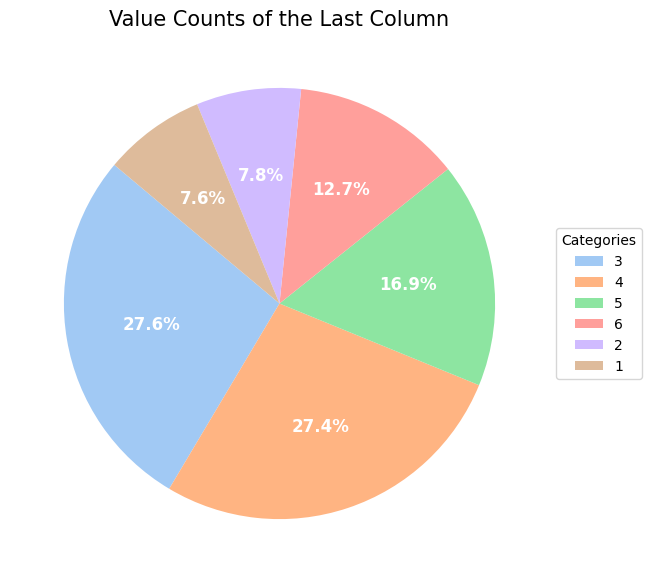

In [17]:


# Get value counts of the last column
last_col_value_counts = df.iloc[:, -1].value_counts()

# Print value counts
print("Value Counts of the Last Column:")
print(last_col_value_counts)

# Define the color palette
colors = sns.color_palette('pastel')[0:len(last_col_value_counts)]

# Plot the value counts as a pie chart
plt.figure(figsize=(10, 7))
wedges, texts, autotexts = plt.pie(last_col_value_counts, autopct='%1.1f%%', colors=colors, startangle=140)

# Add a legend
plt.legend(wedges, last_col_value_counts.index, title="Categories", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

# Add a title
plt.title('Value Counts of the Last Column', fontsize=15)

# Style the text
plt.setp(autotexts, size=12, weight='bold', color='white')
plt.setp(texts, size=12)

# Display the pie chart
plt.show()


### Value_counts of all columns

In [18]:
for col in df.columns:
    print('Column :', col)
    print(df[col].value_counts())
    print('*'*35)
    

Column : Age
Age
20-30          253
15-20          166
40 or above     48
30-40           30
Name: count, dtype: int64
***********************************
Column : Gender
Gender
Male      252
Female    245
Name: count, dtype: int64
***********************************
Column : Free Time Activity
Free Time Activity
Playing sports with your friends.                                            133
Lying on your couch and watching Netflix.                                    128
Reading a book in the garden during summer.                                   78
Embracing your artistic skills by painting or sketching.                      59
Developing your skills in trading or learning about the financial market.     42
Thinking about business ideas while watching Shark Tank.                      39
Writing and developing programming codes.                                     18
Name: count, dtype: int64
***********************************
Column : Work Environment
Work Environment
Office settin

#### Data is imbalalnced

## Now Let's visualise our data and look for insights.

### Univariate Analysis

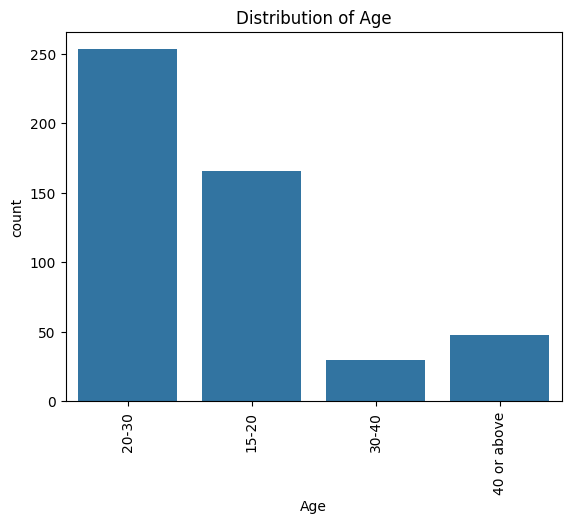

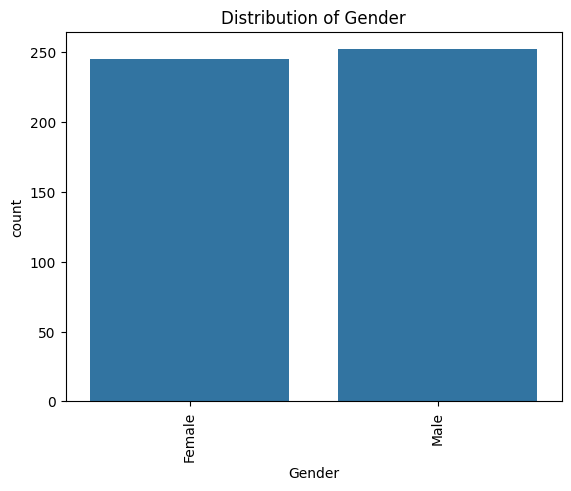

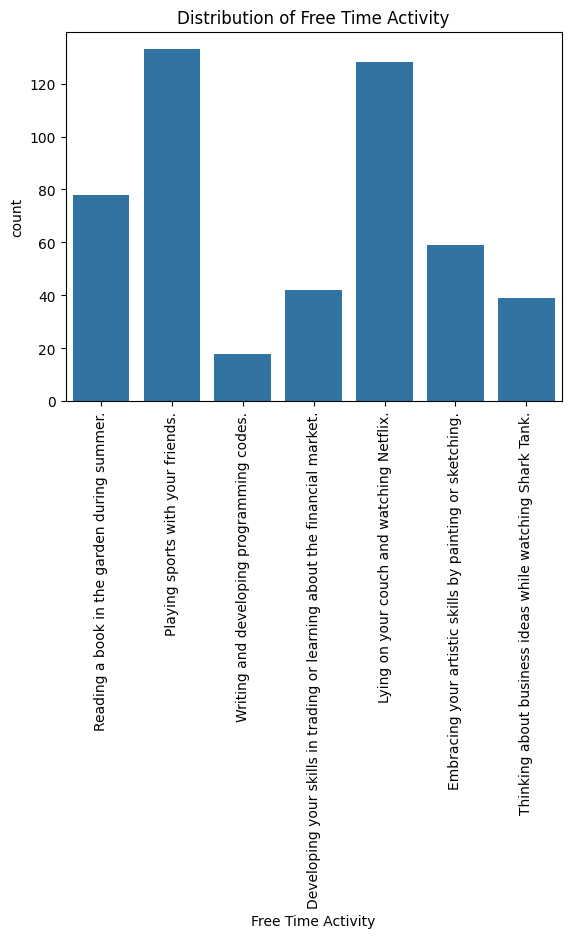

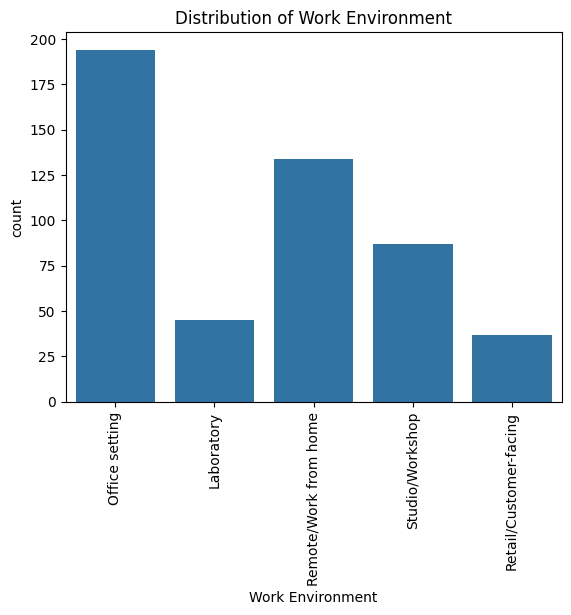

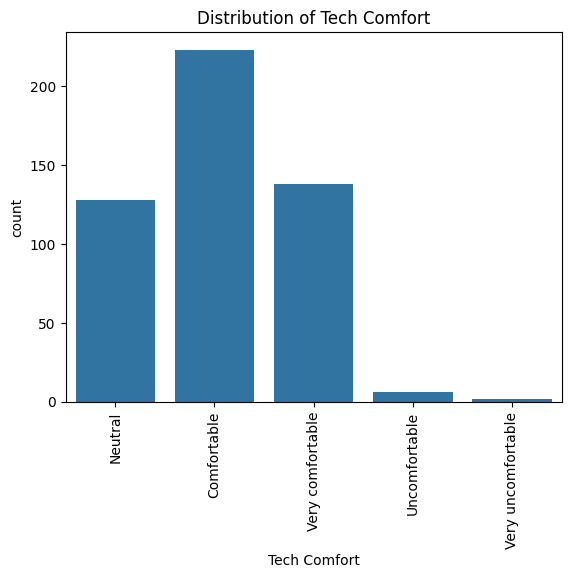

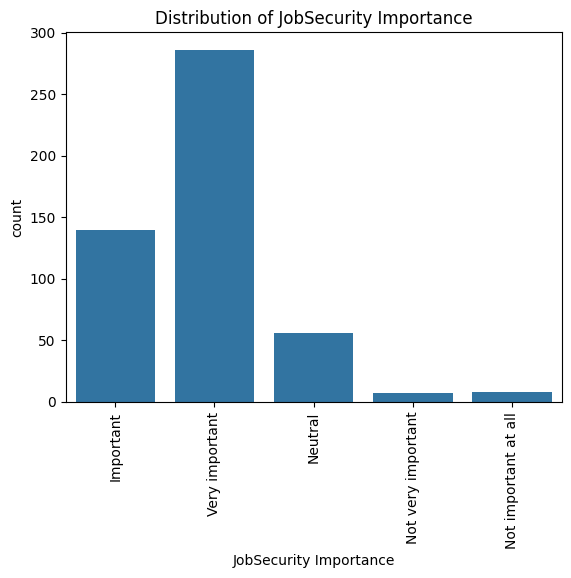

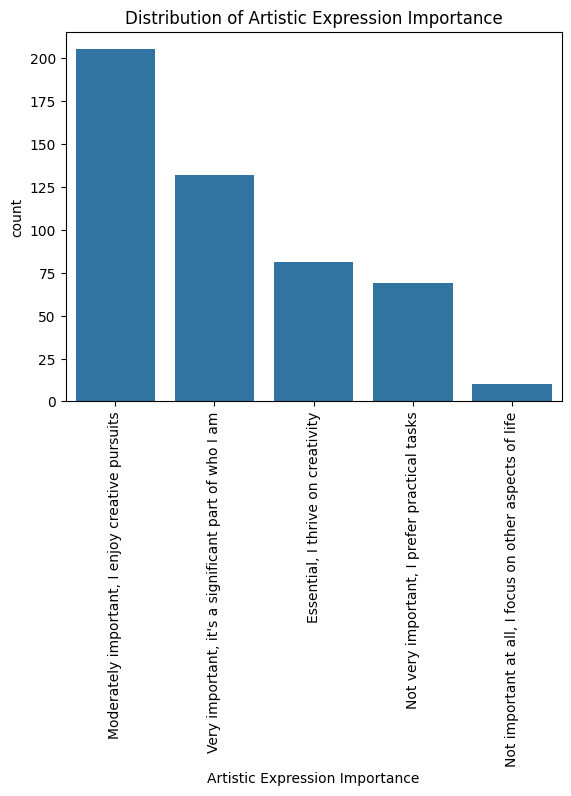

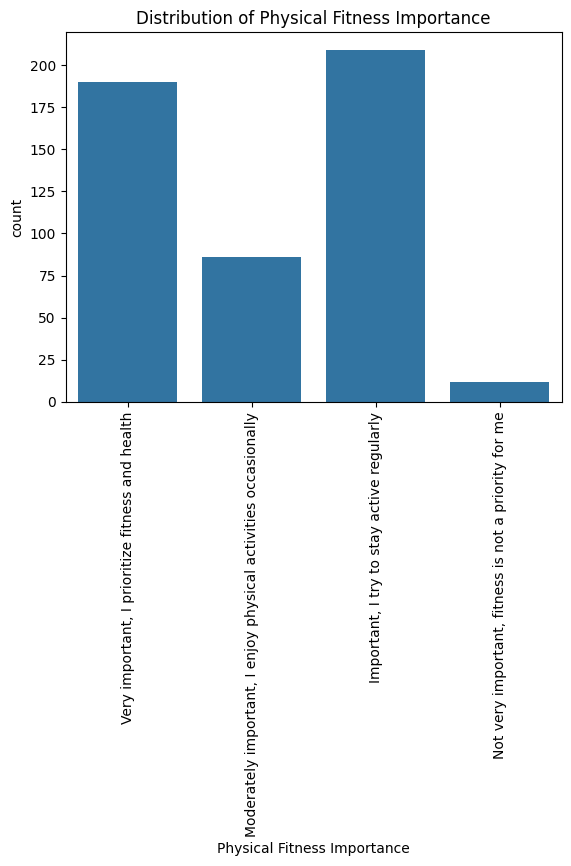

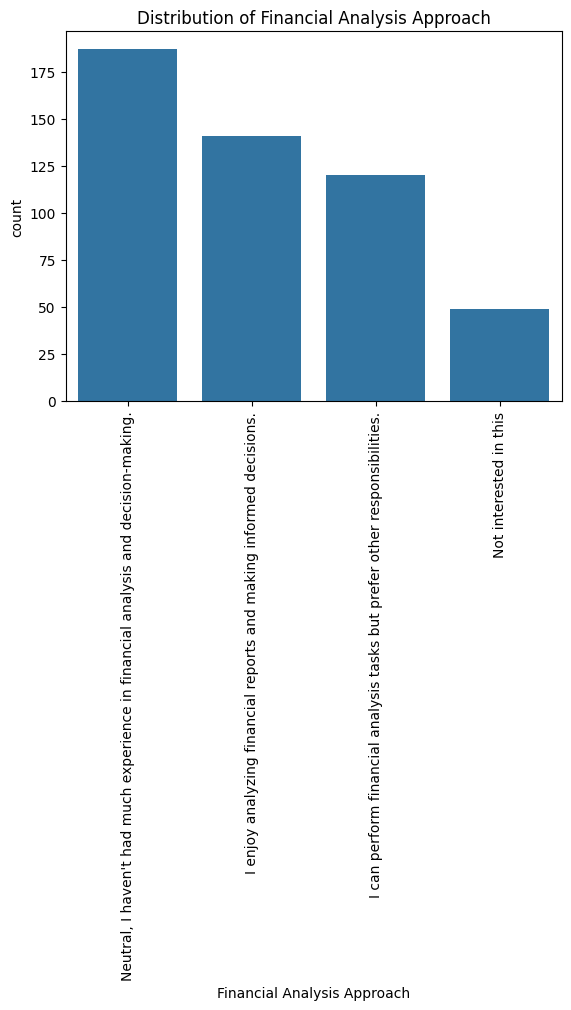

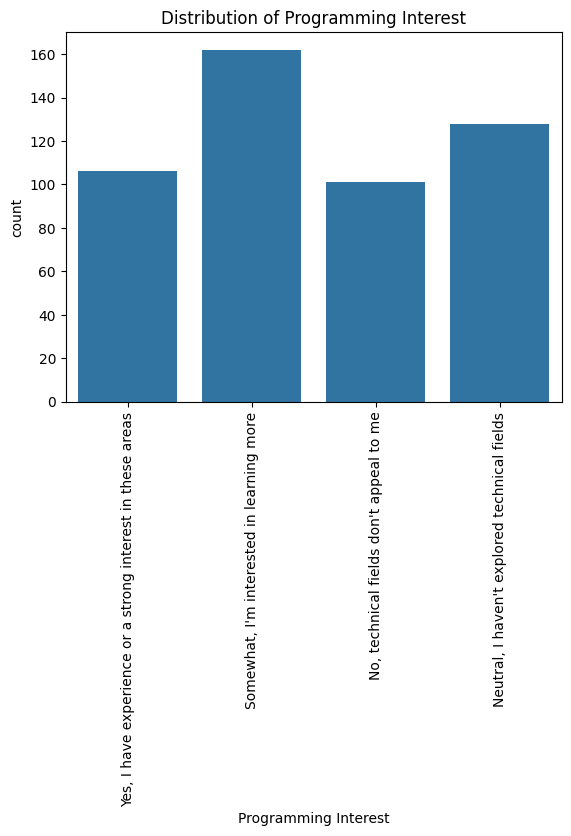

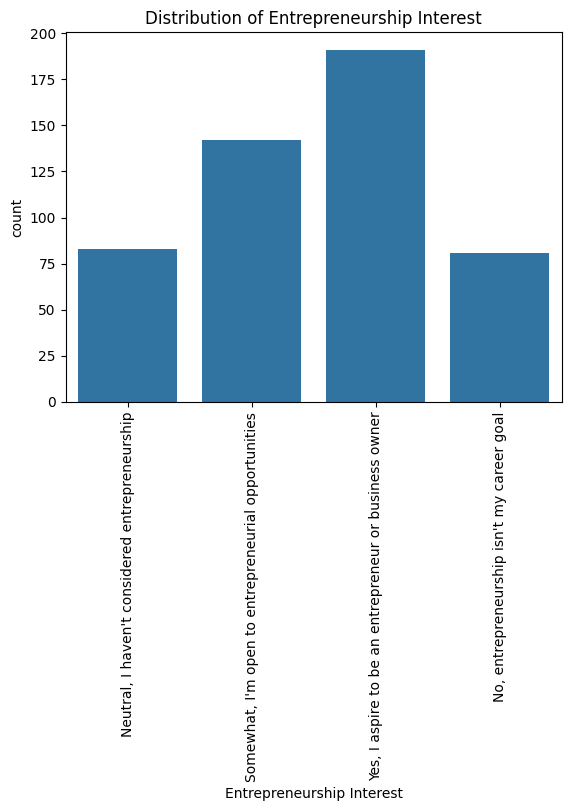

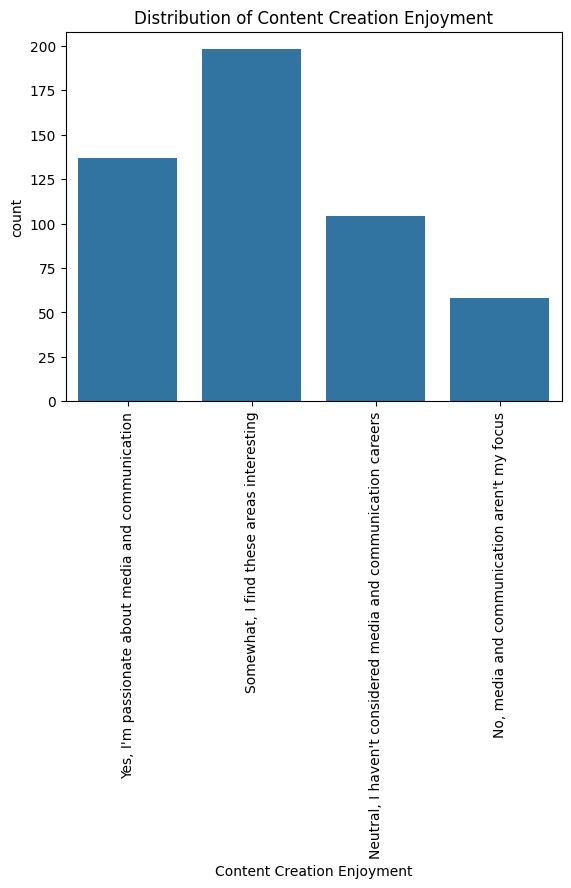

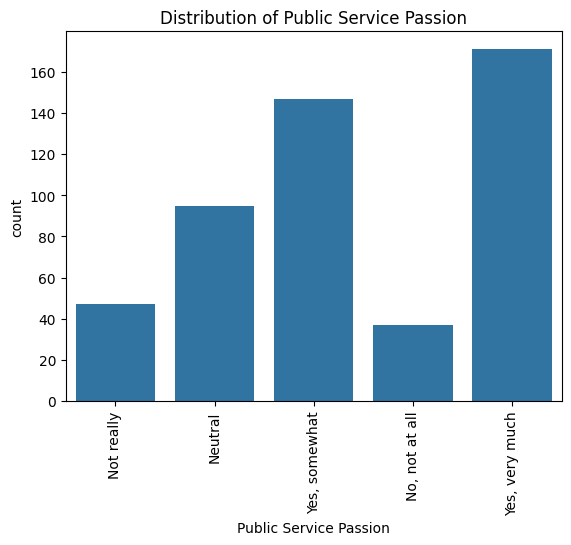

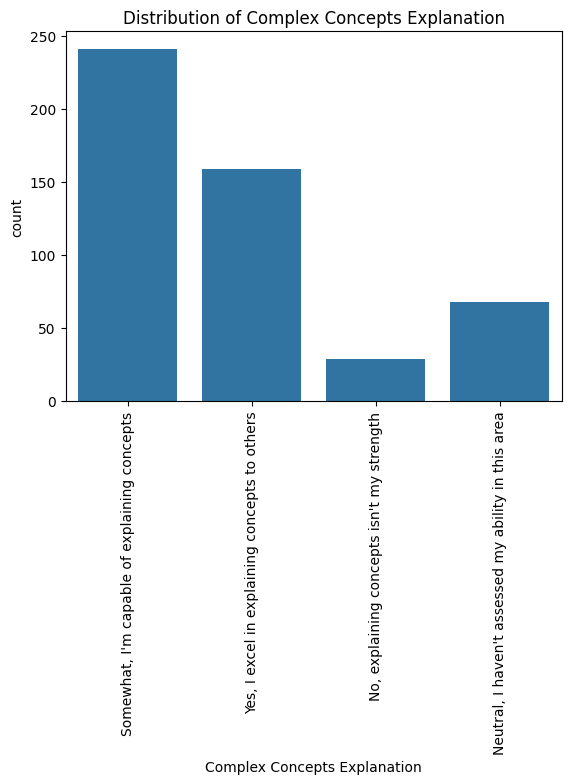

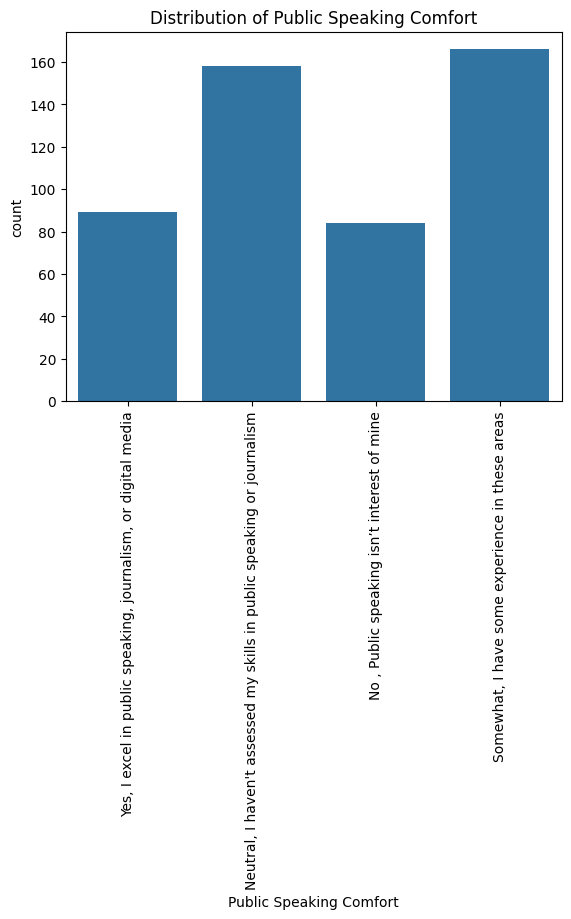

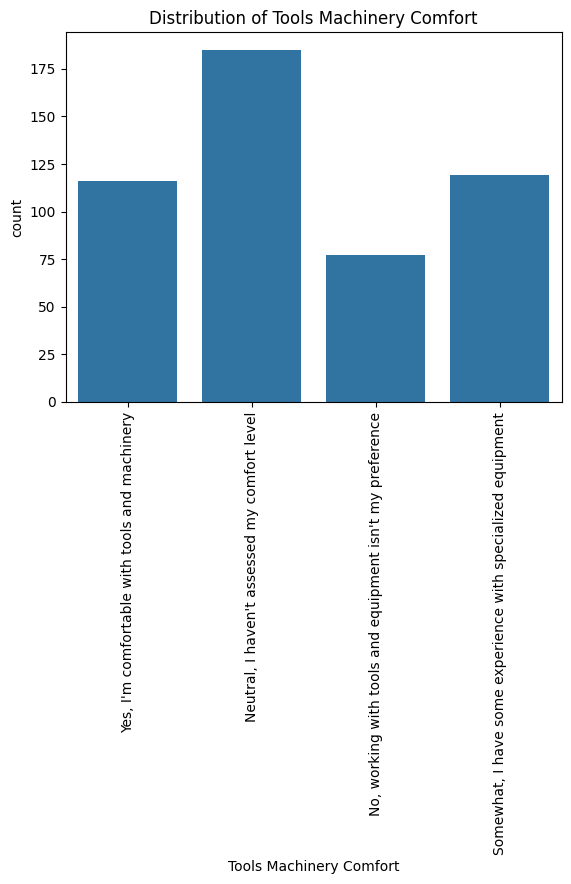

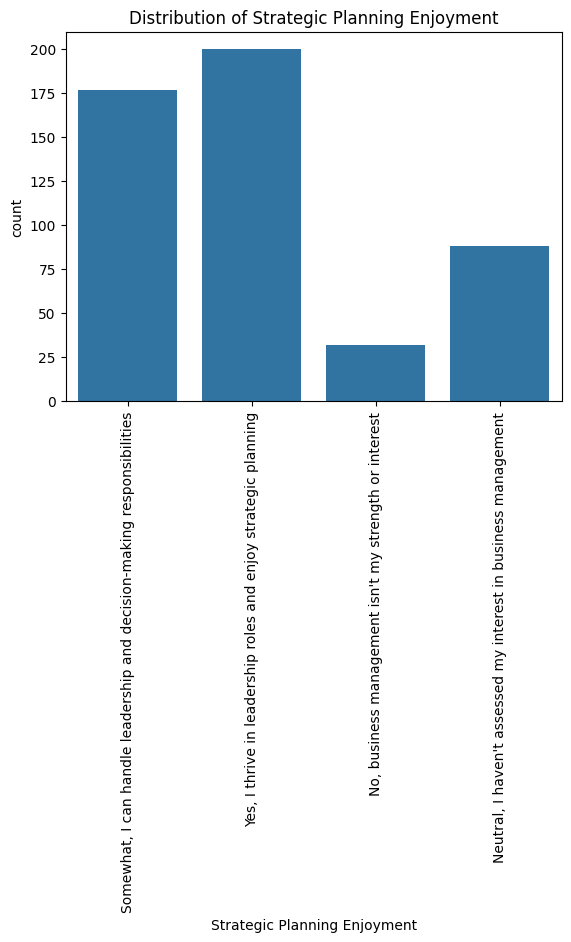

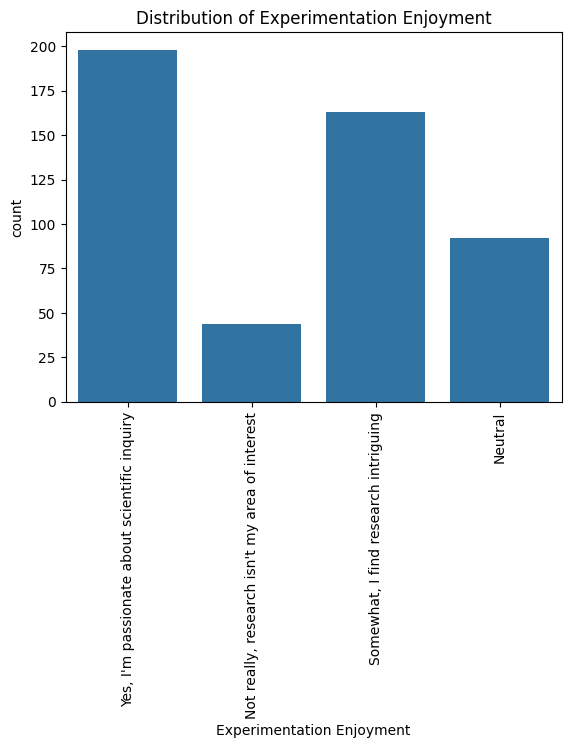

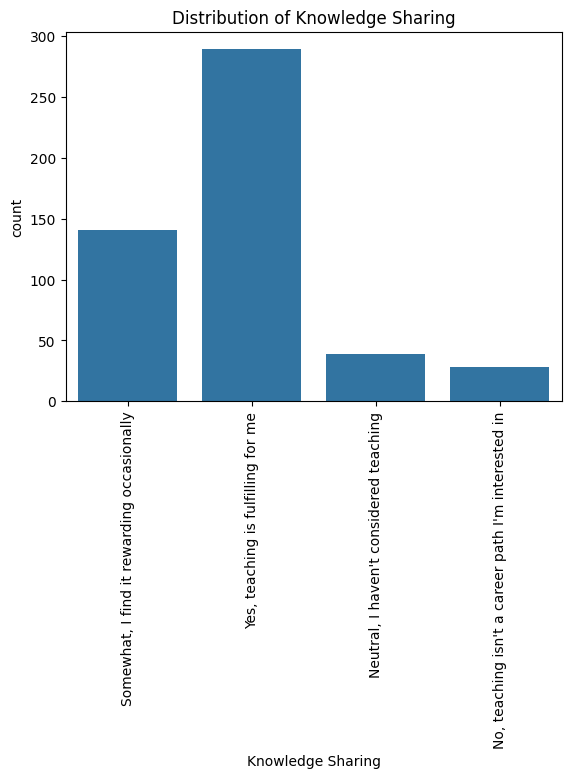

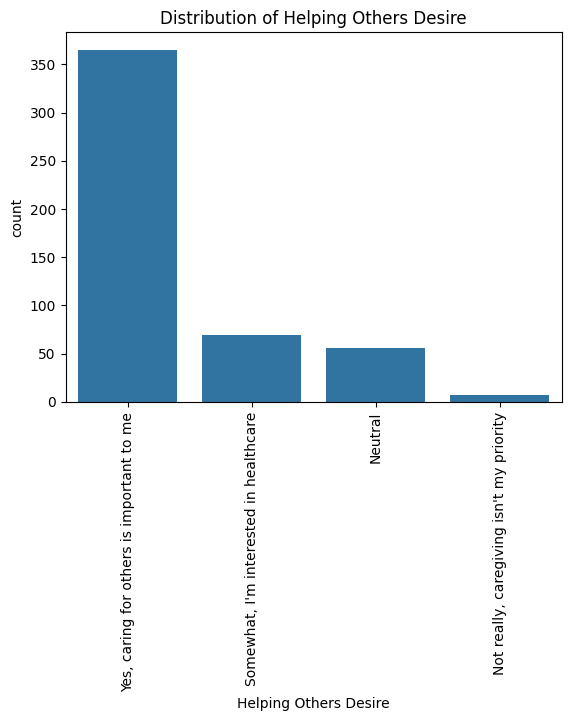

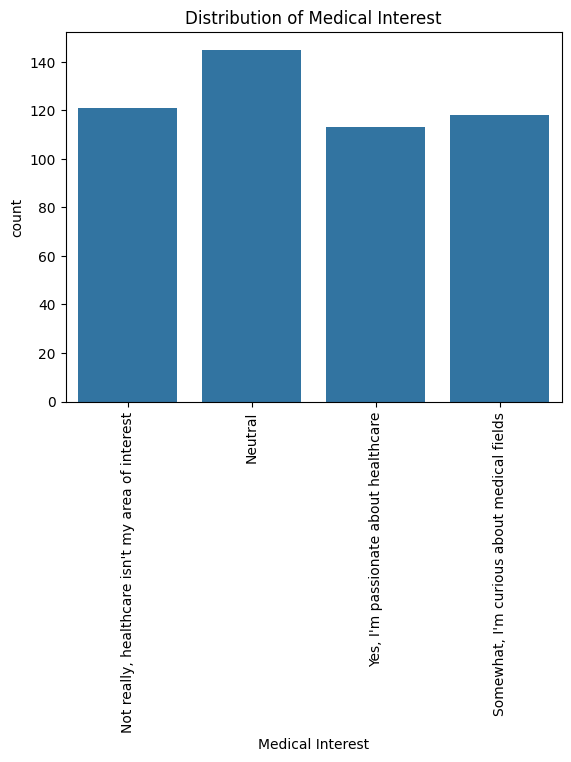

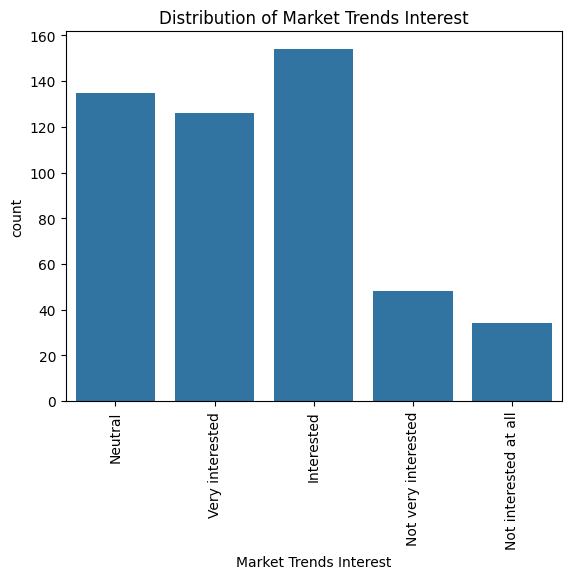

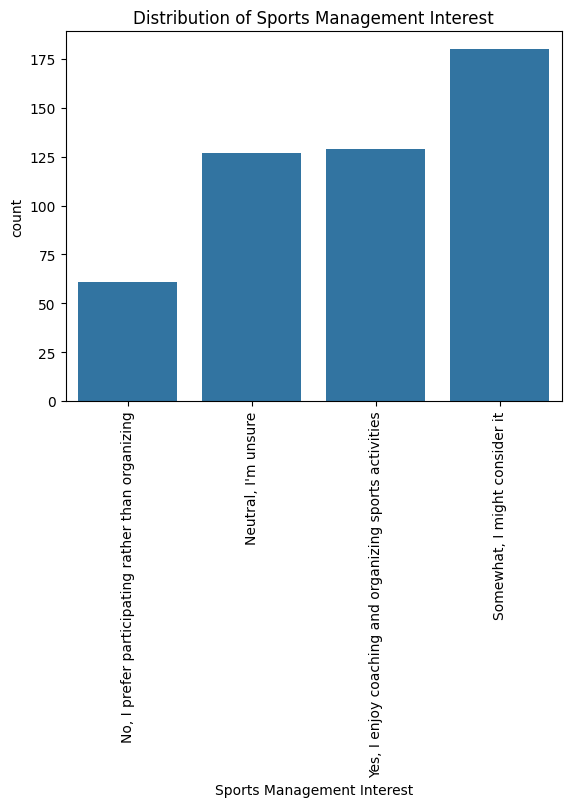

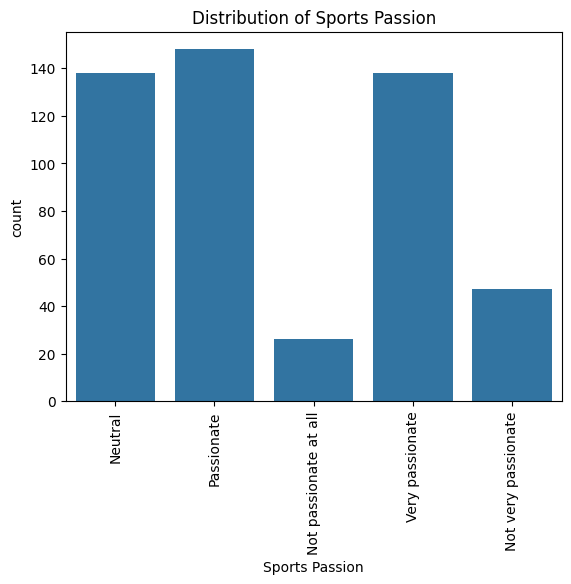

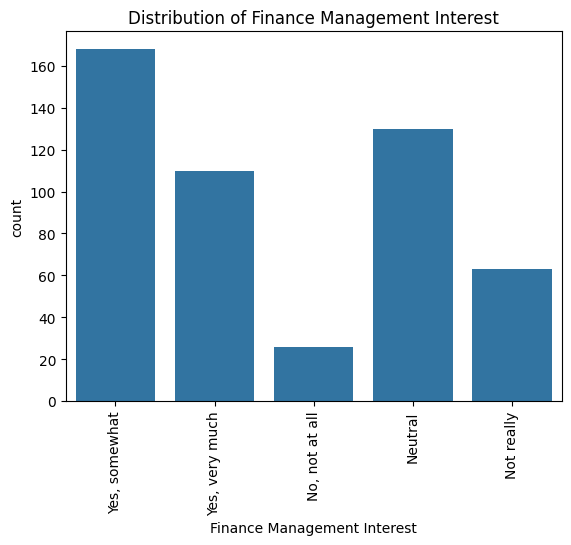

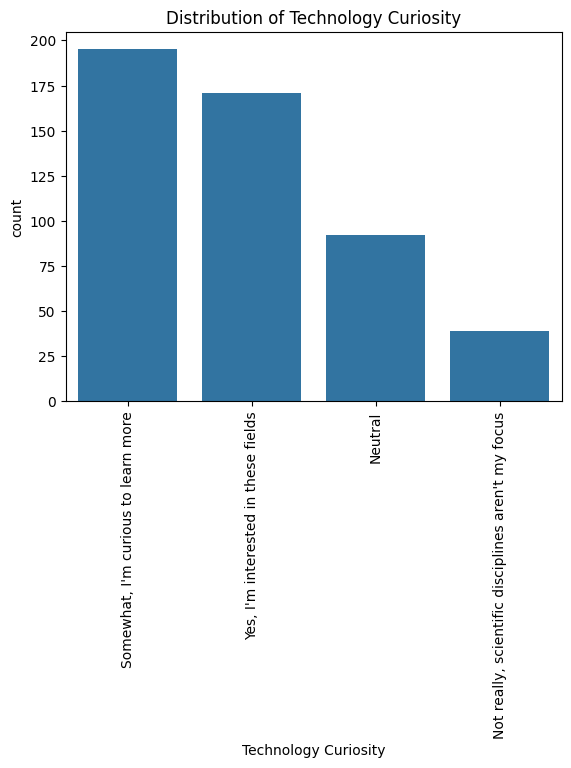

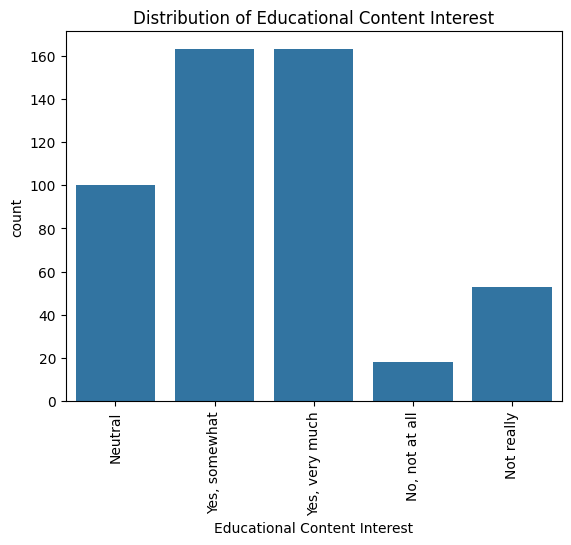

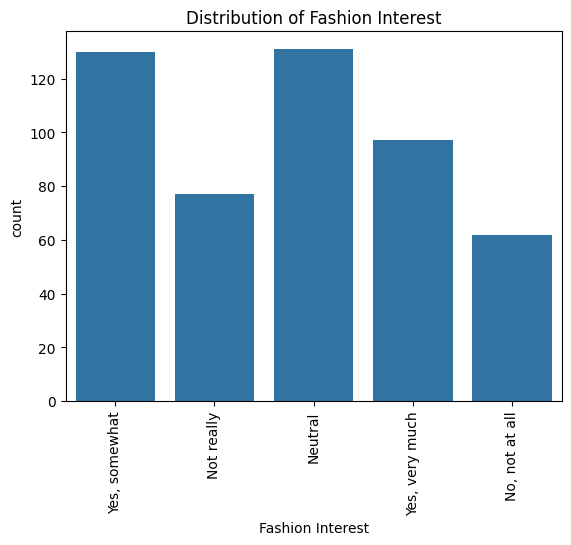

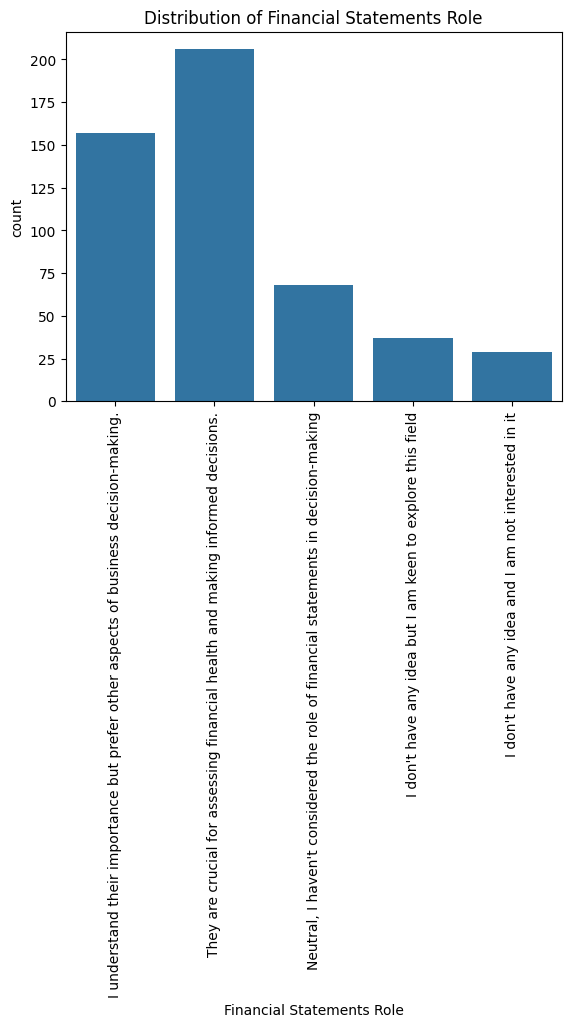

In [19]:
for column in df.columns[:-1]:  # Exclude Timestamp, Name, and target column
    if column == 'Skills Strengths':
        continue
    sns.countplot(data=df, x=column)
    plt.title(f'Distribution of {column}')
    plt.xticks(rotation=90)
    plt.show()


### Bivariate Analysis

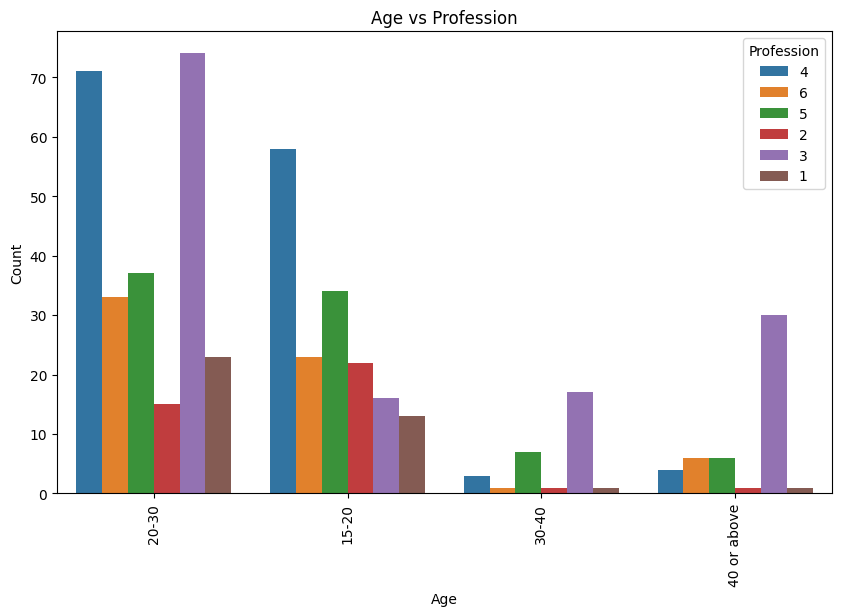

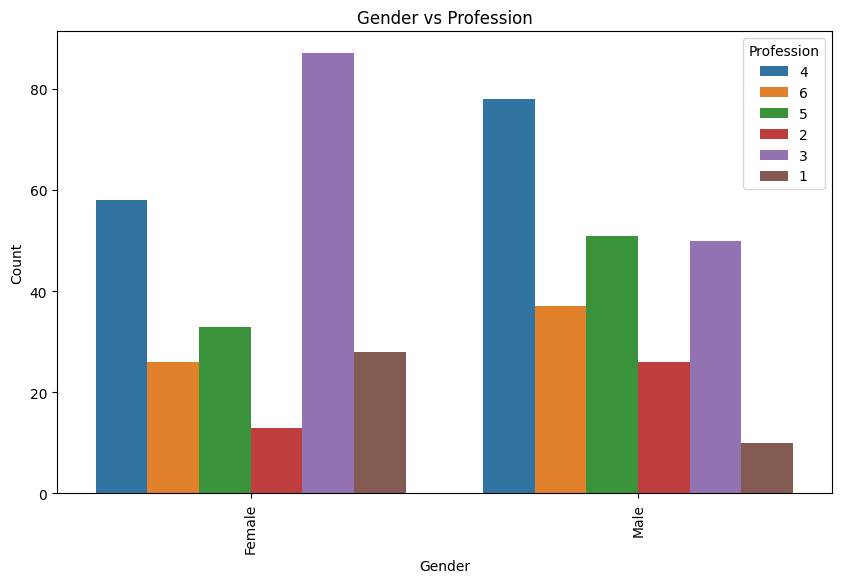

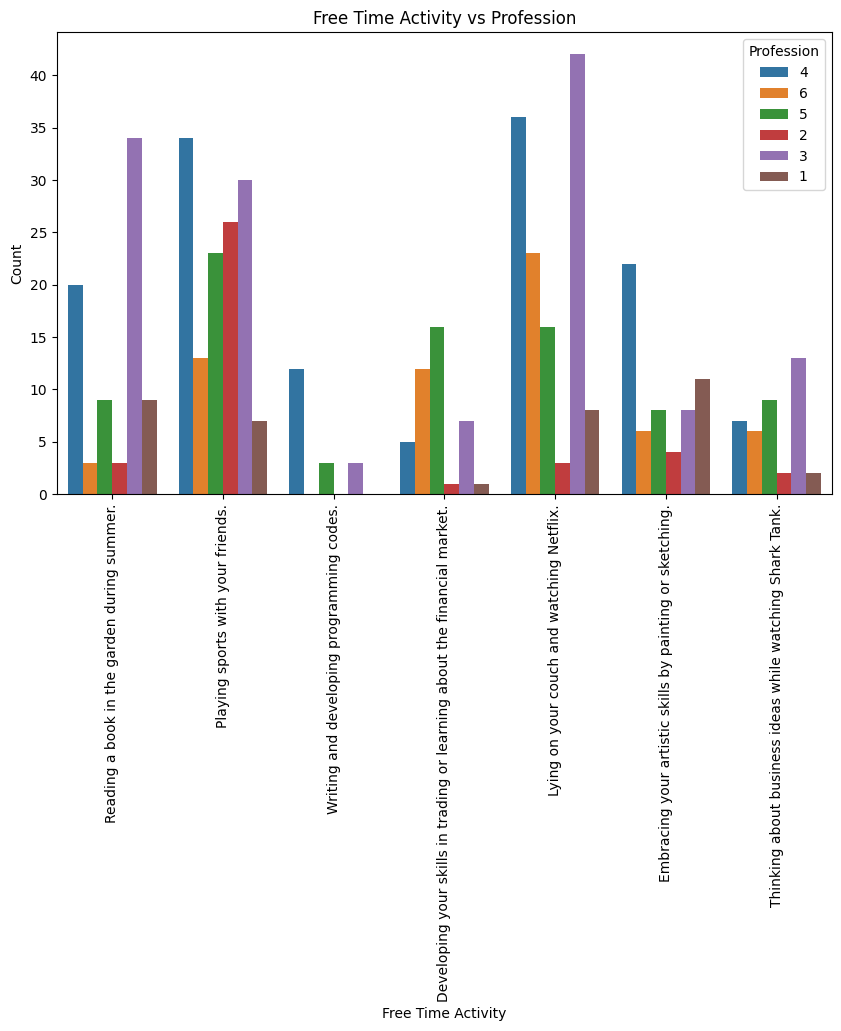

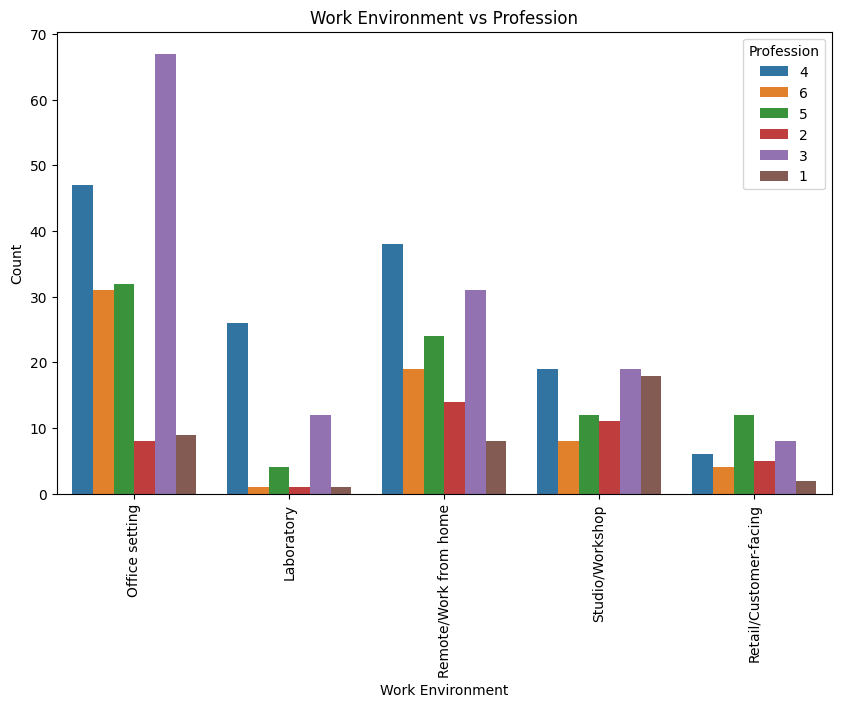

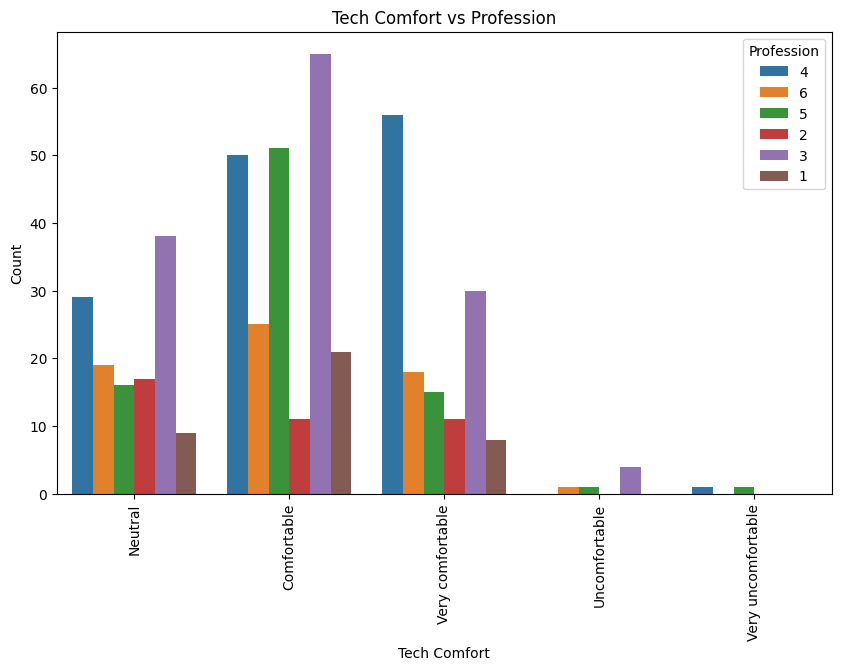

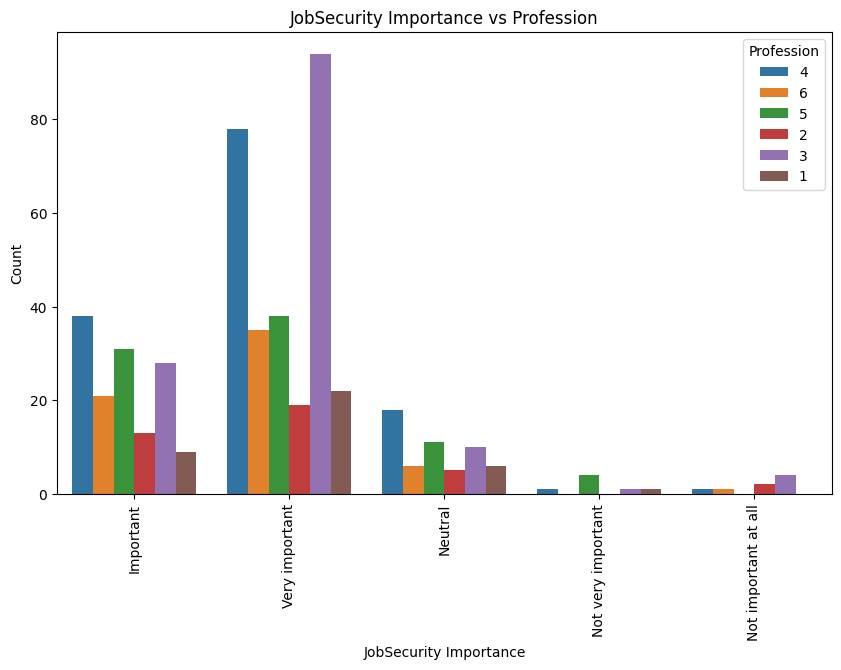

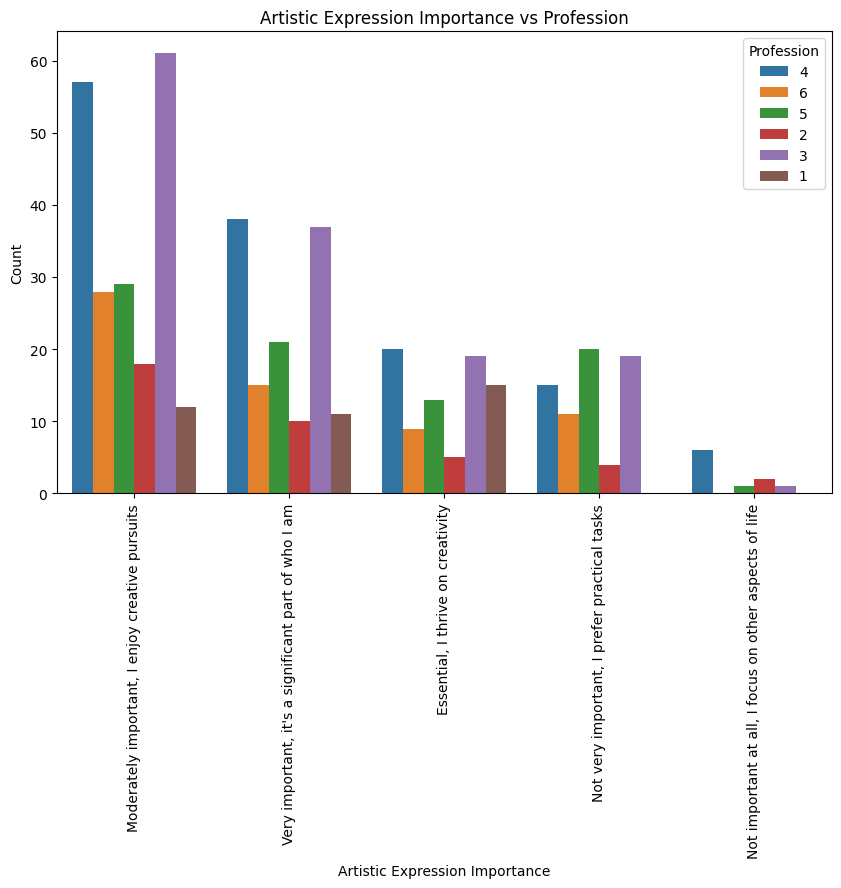

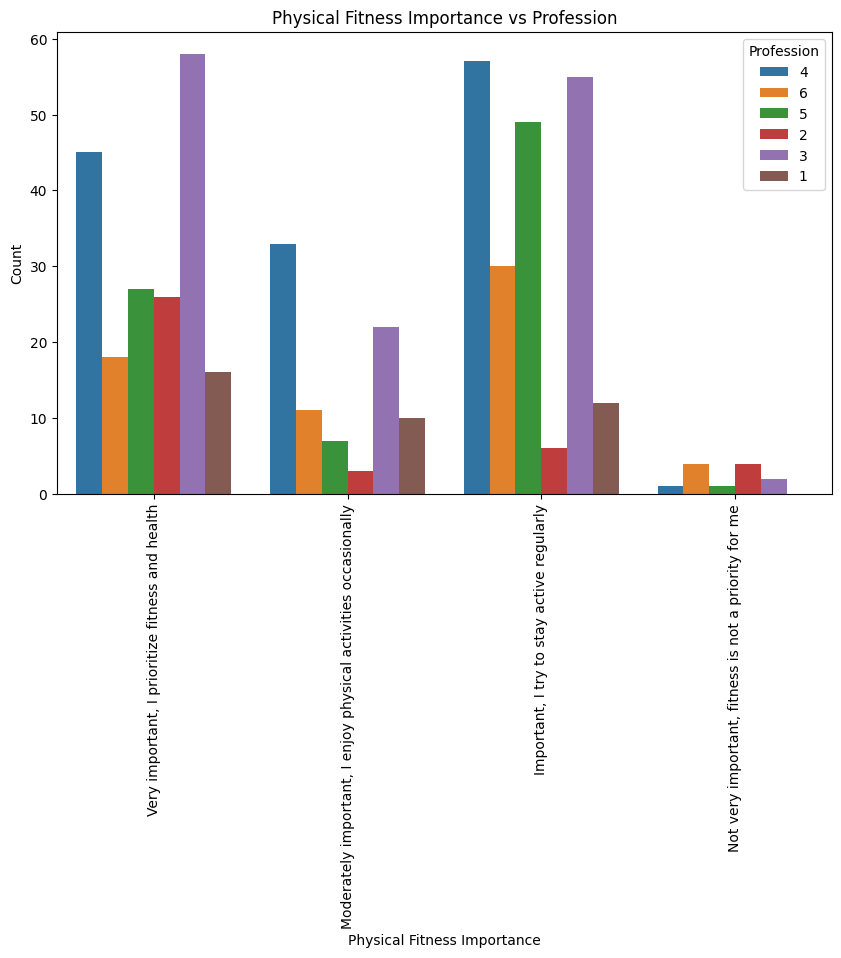

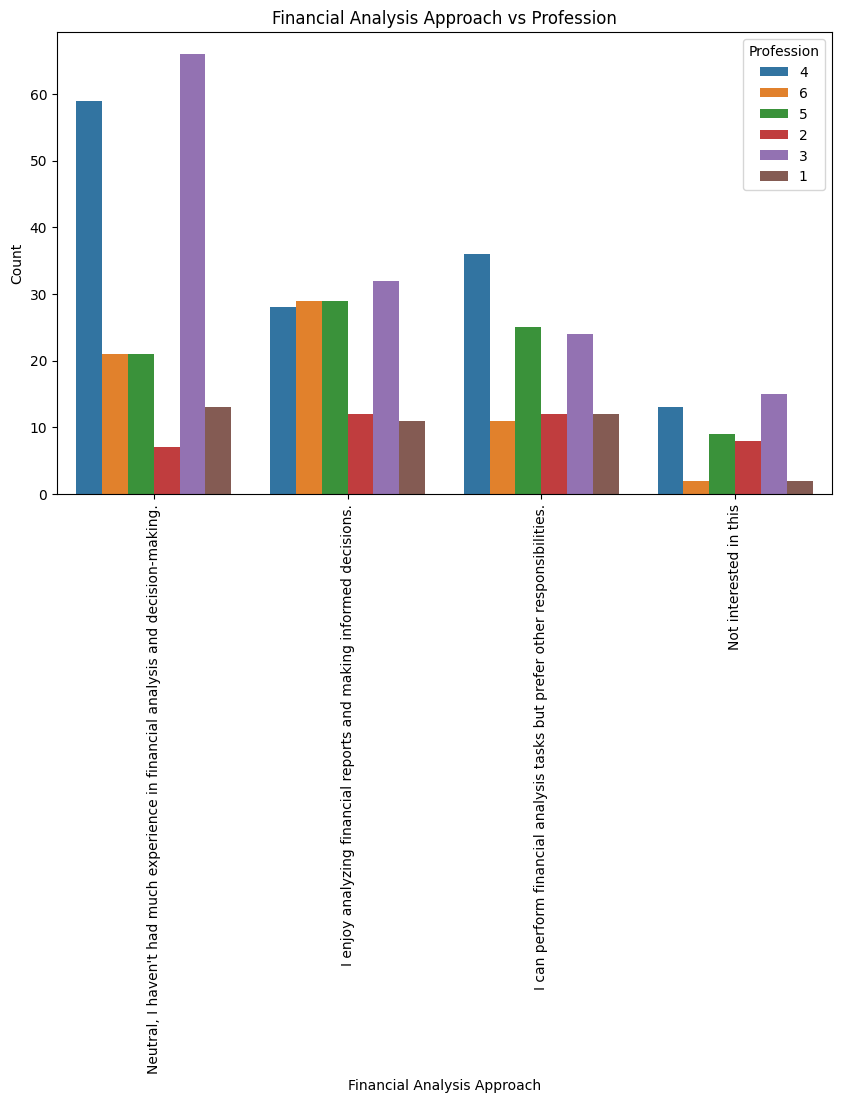

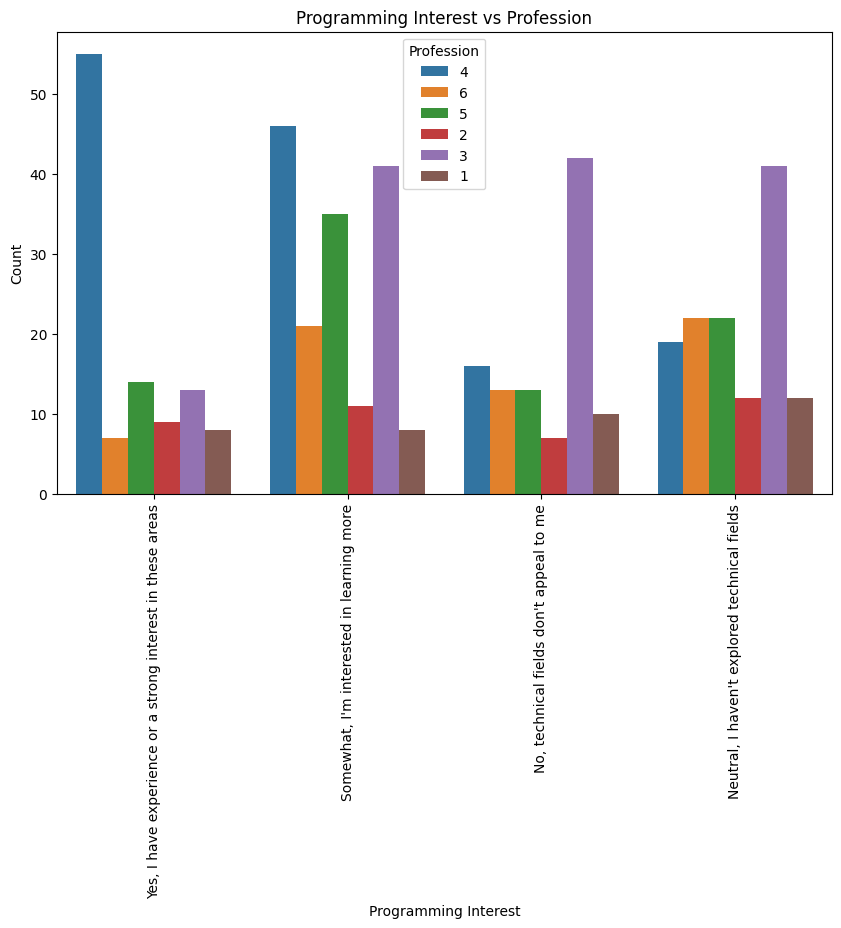

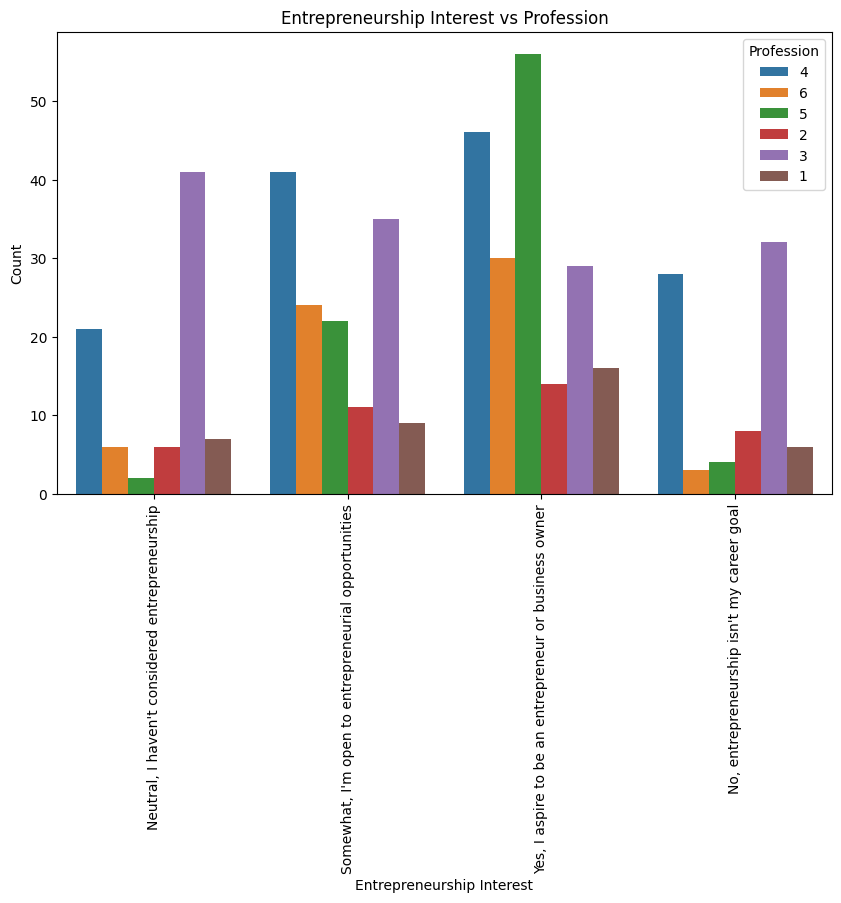

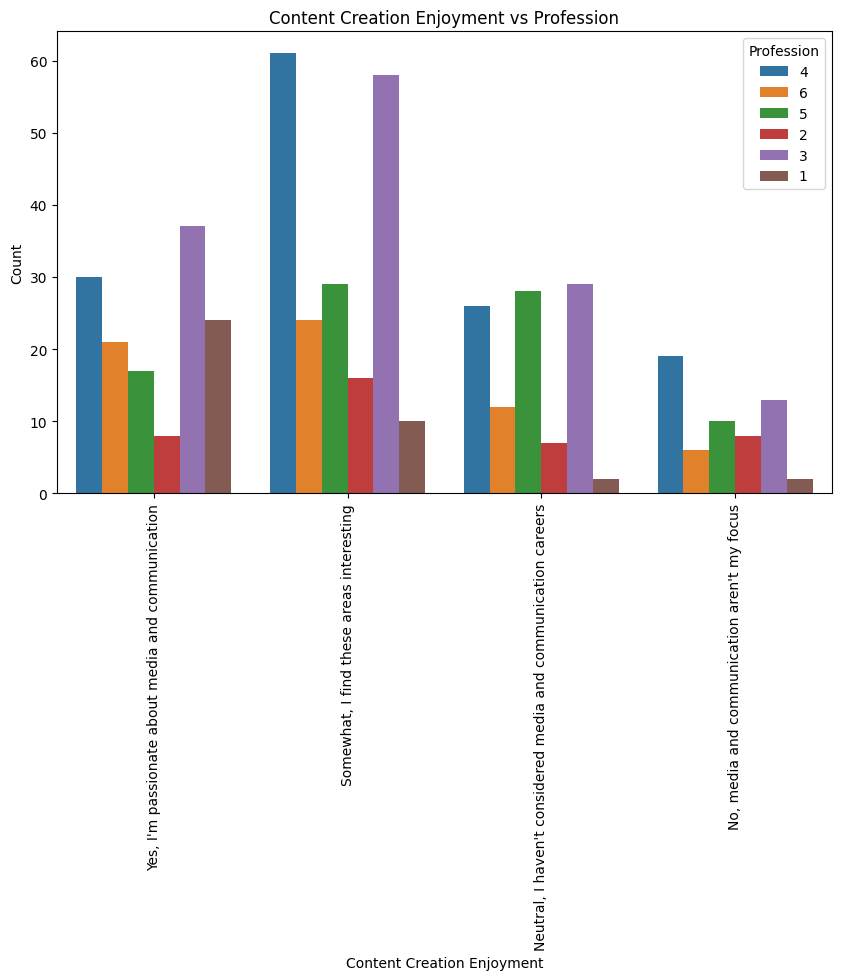

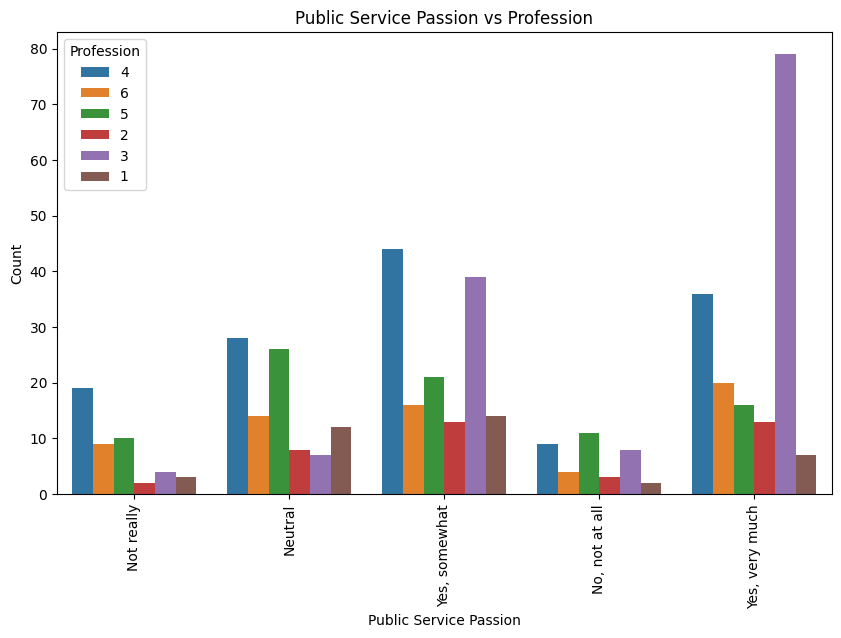

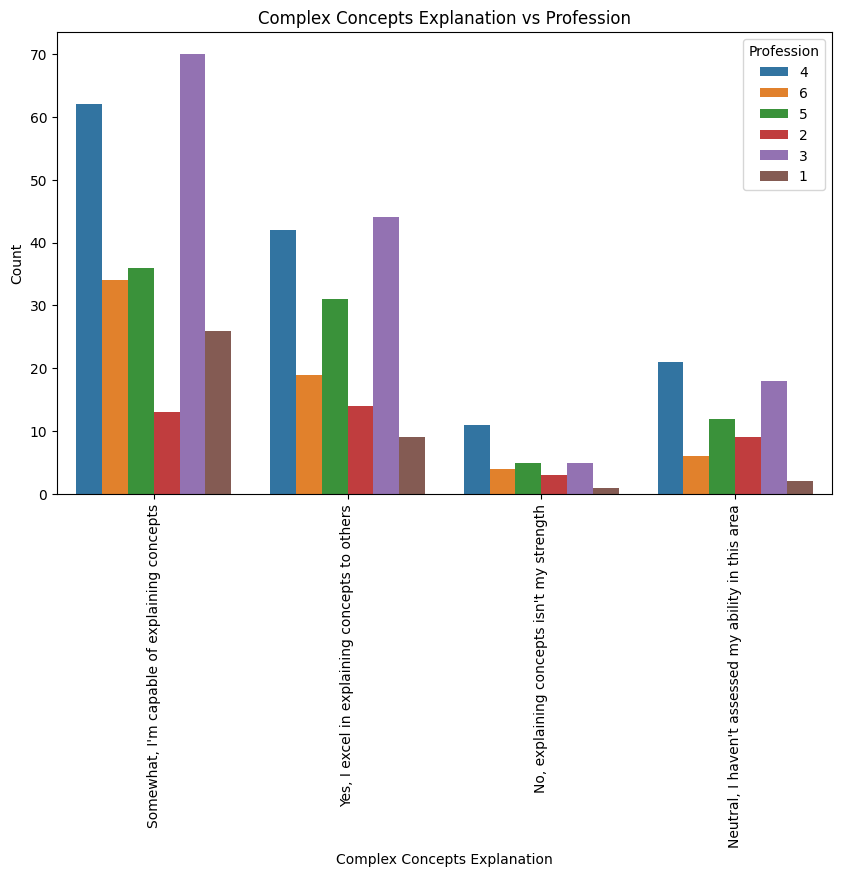

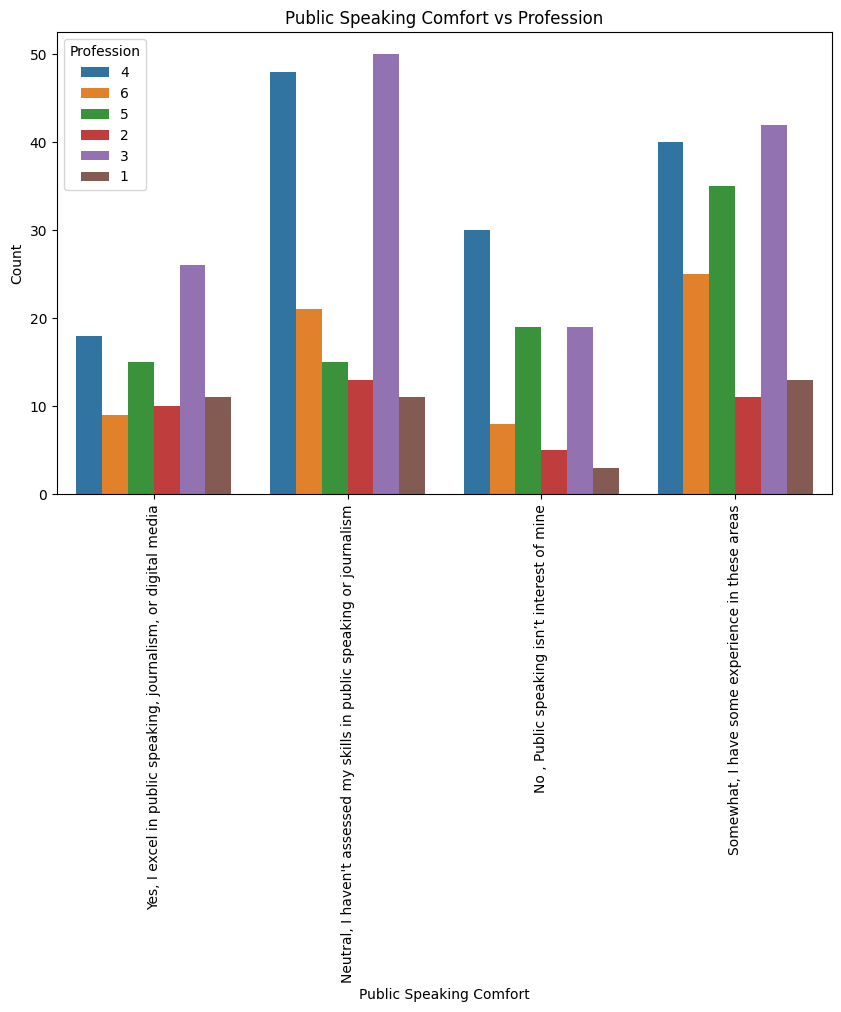

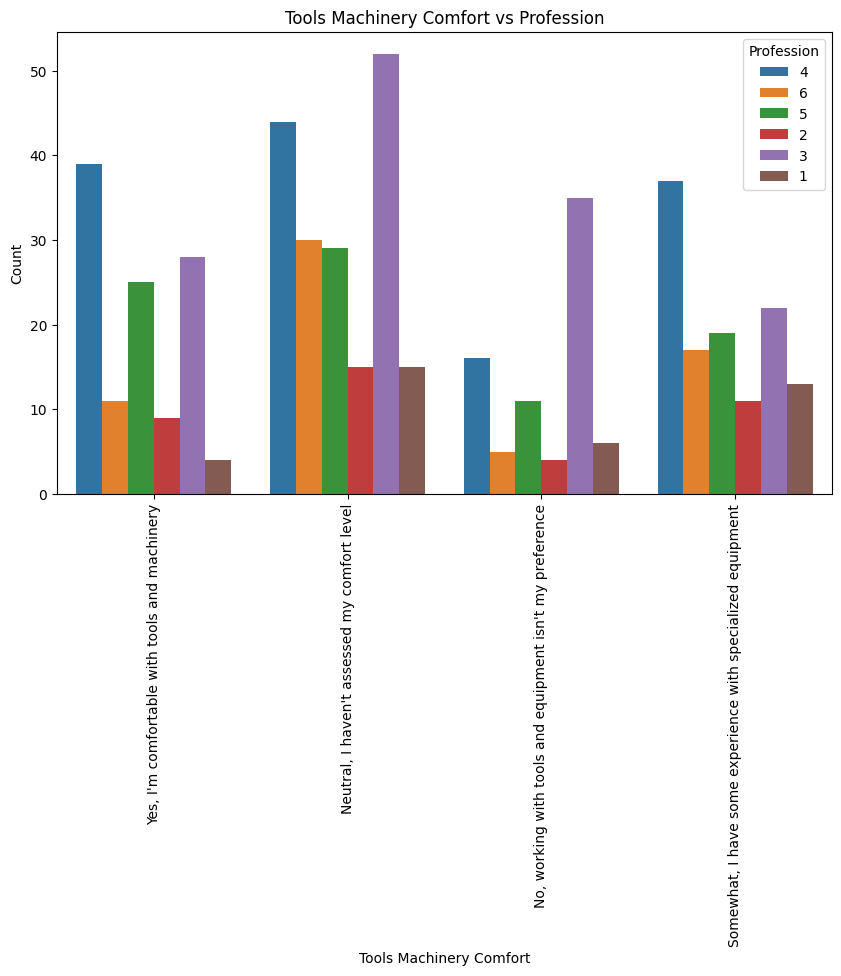

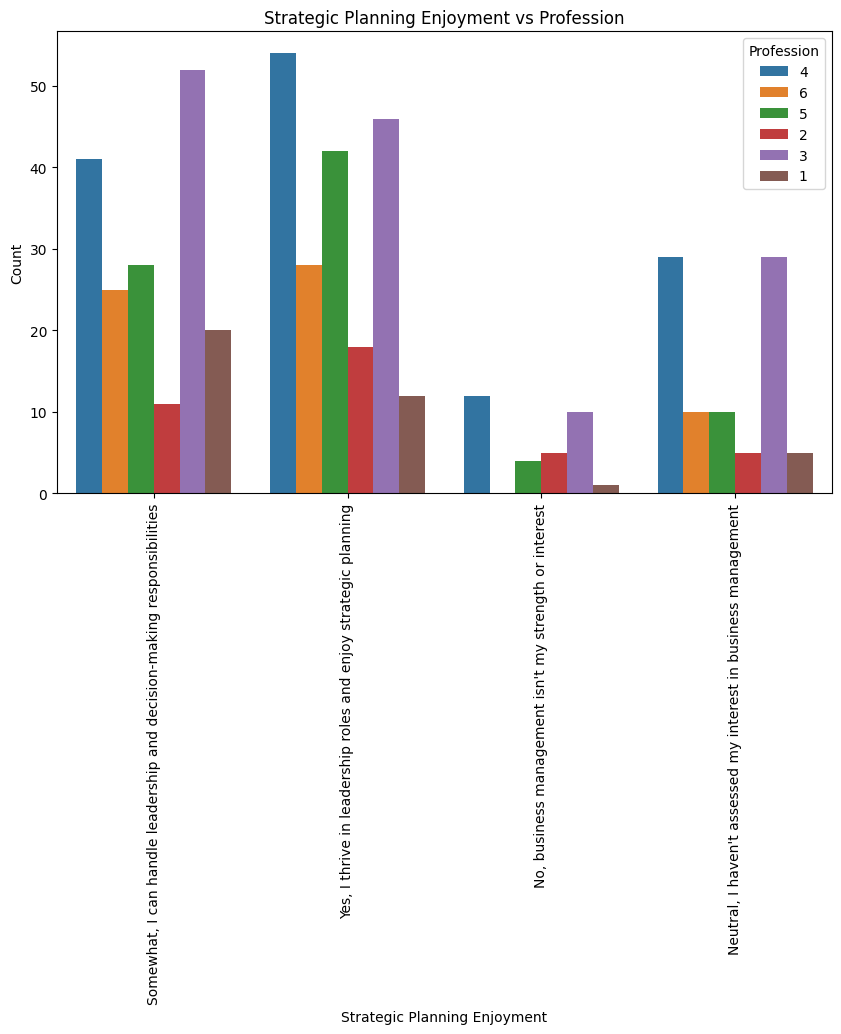

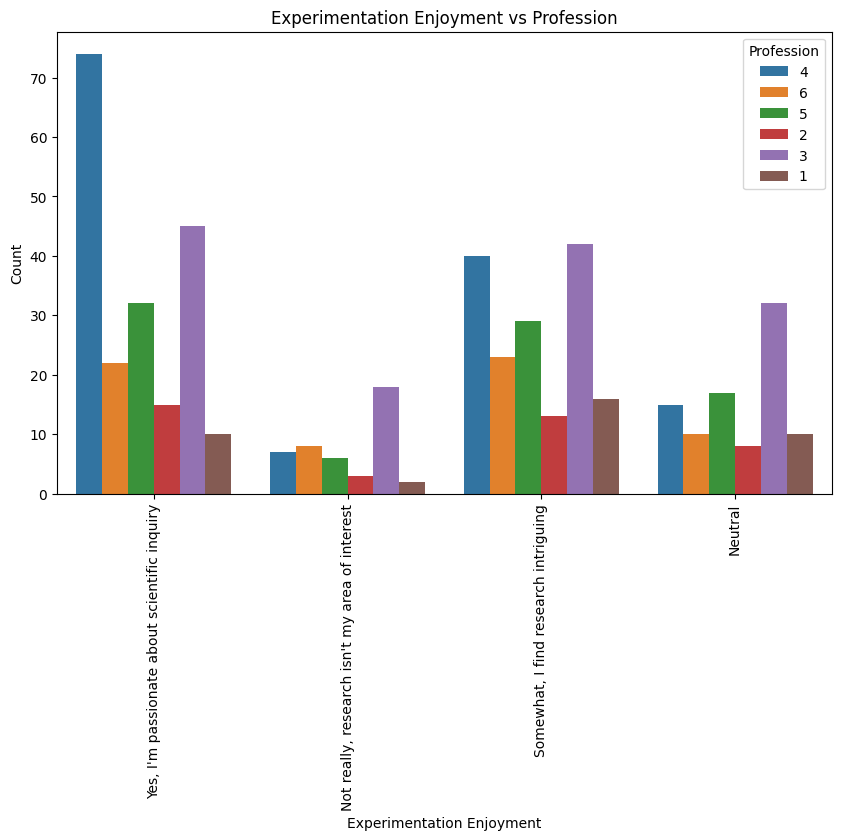

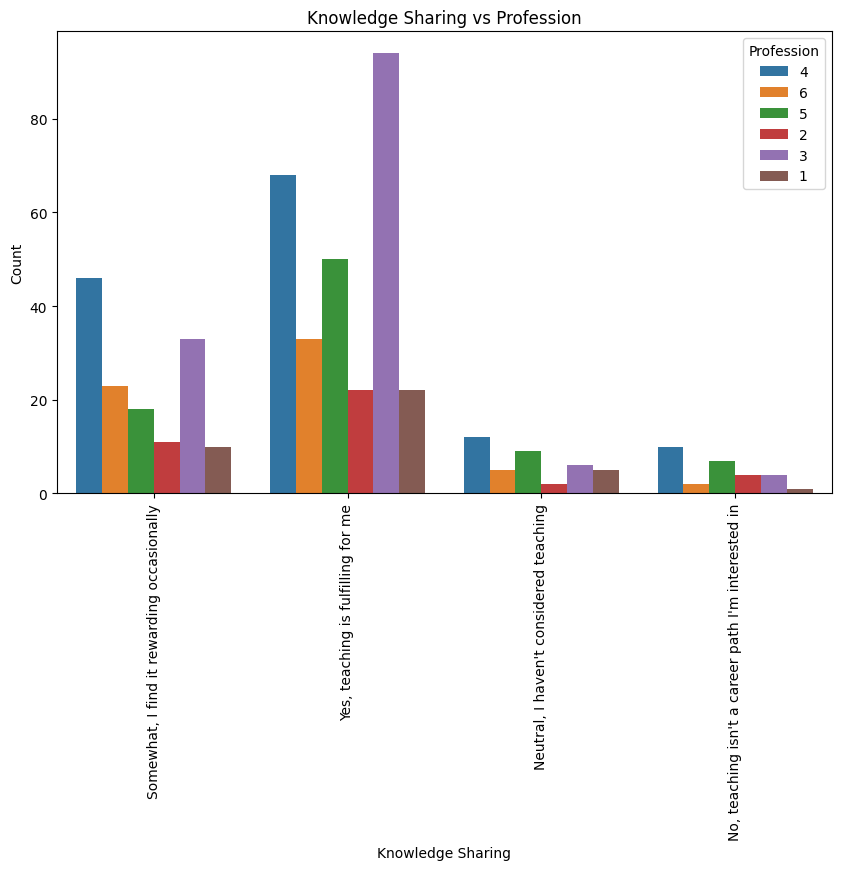

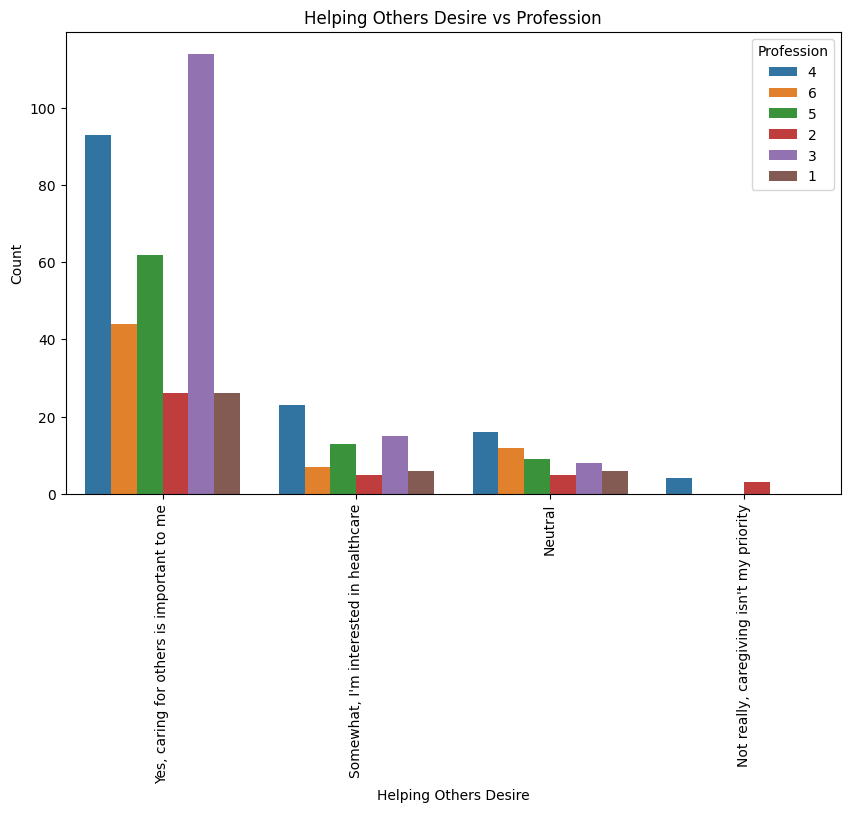

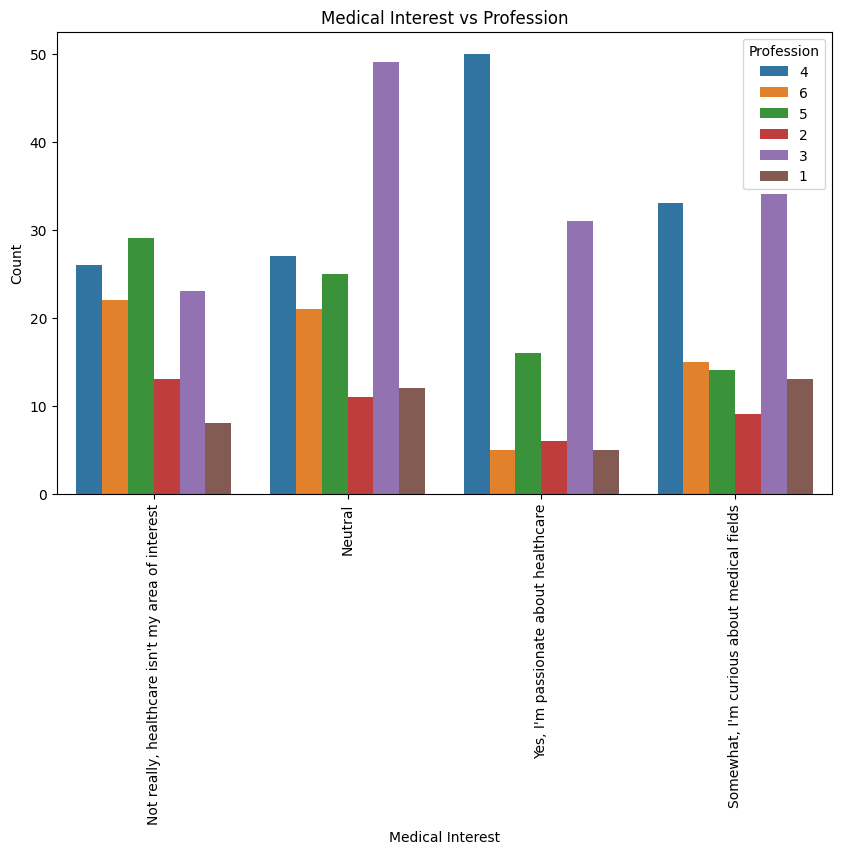

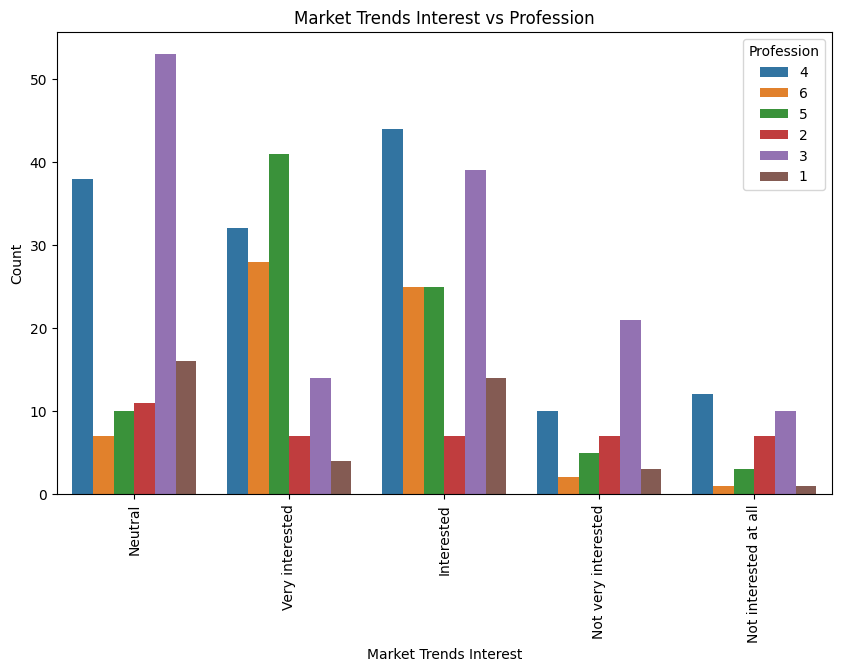

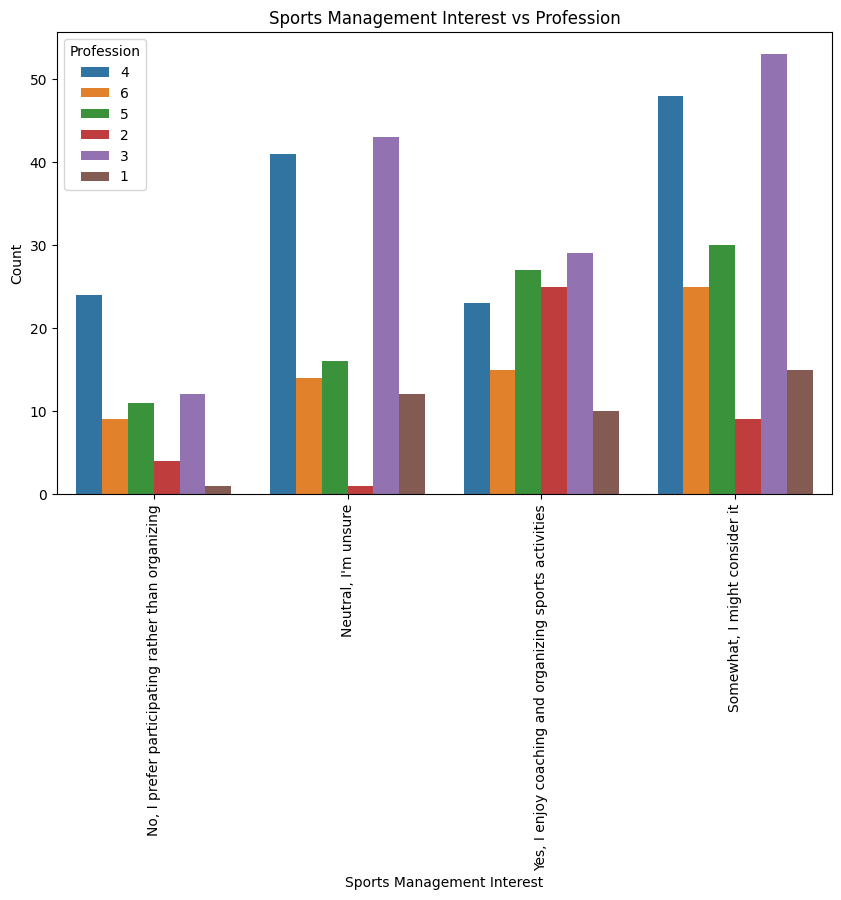

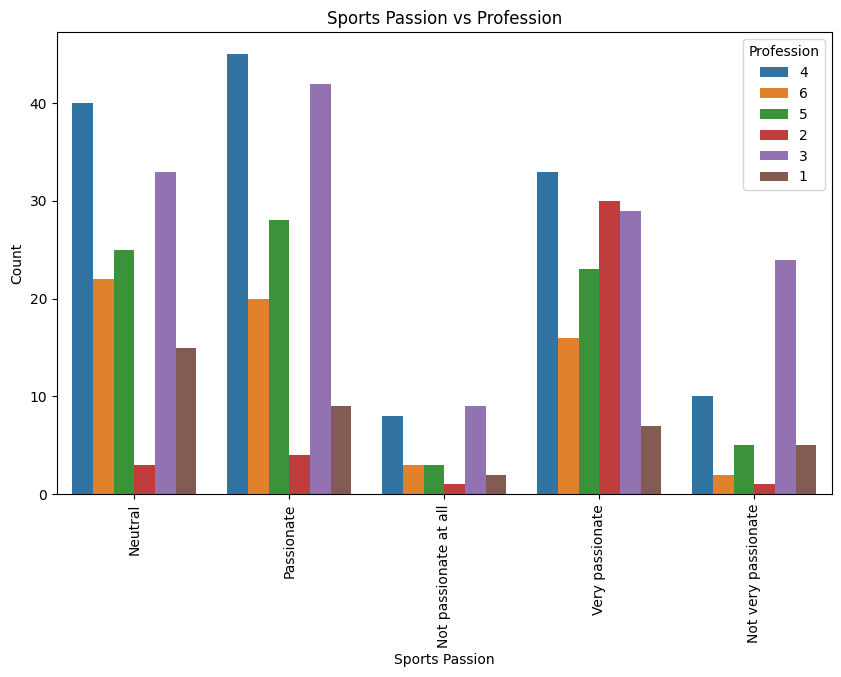

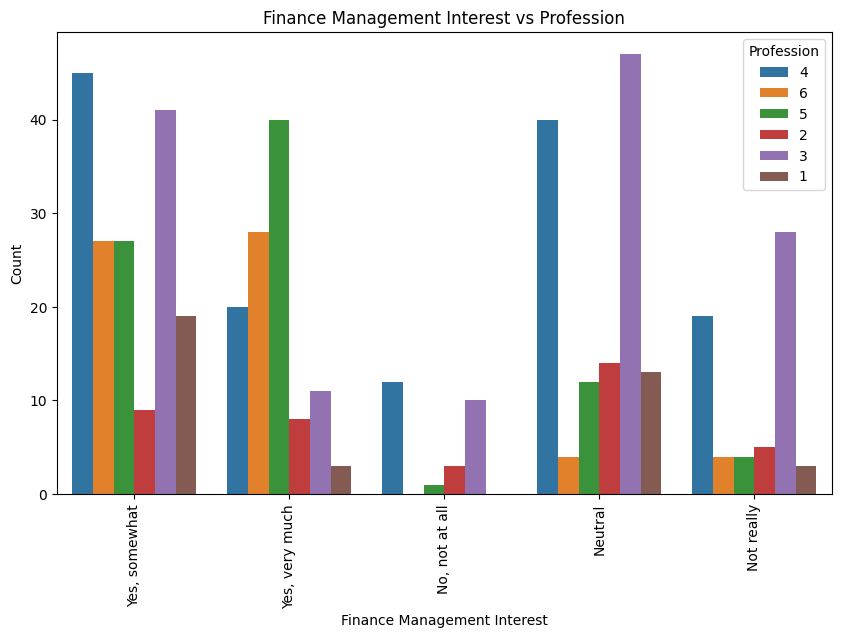

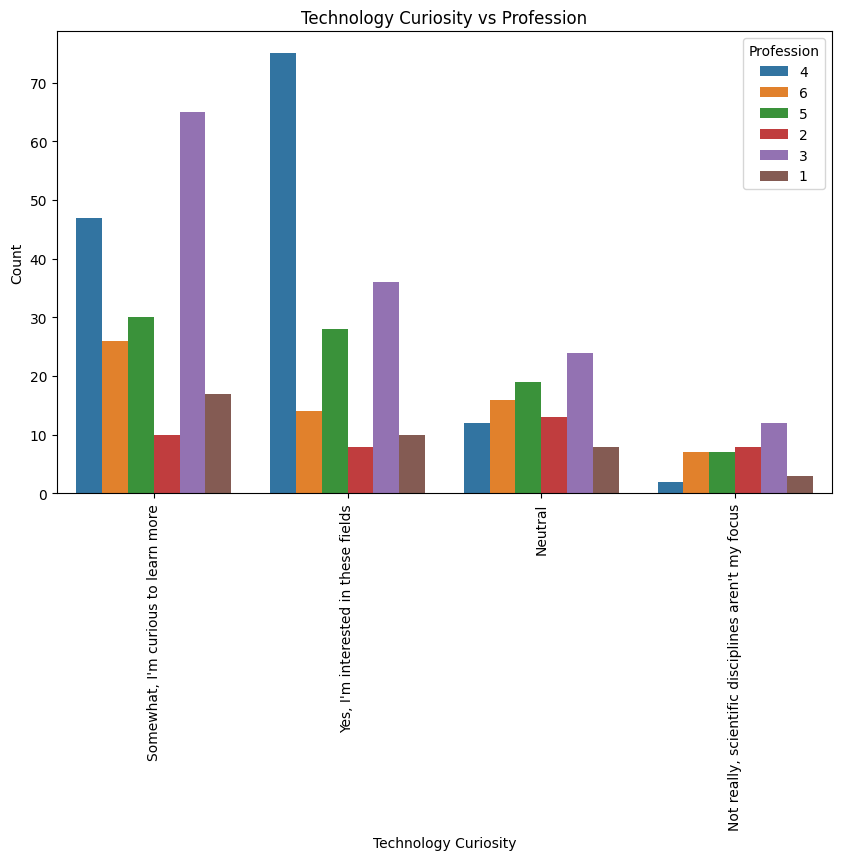

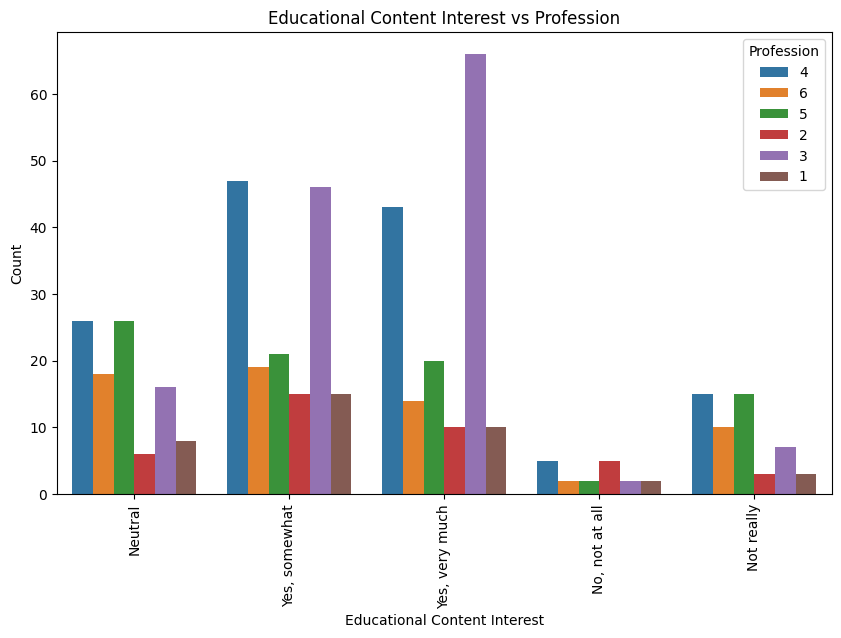

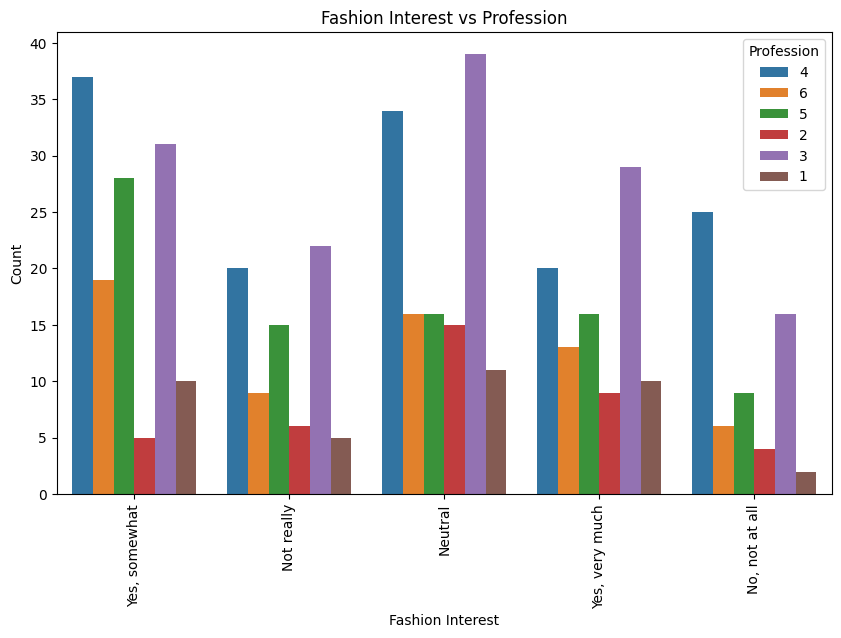

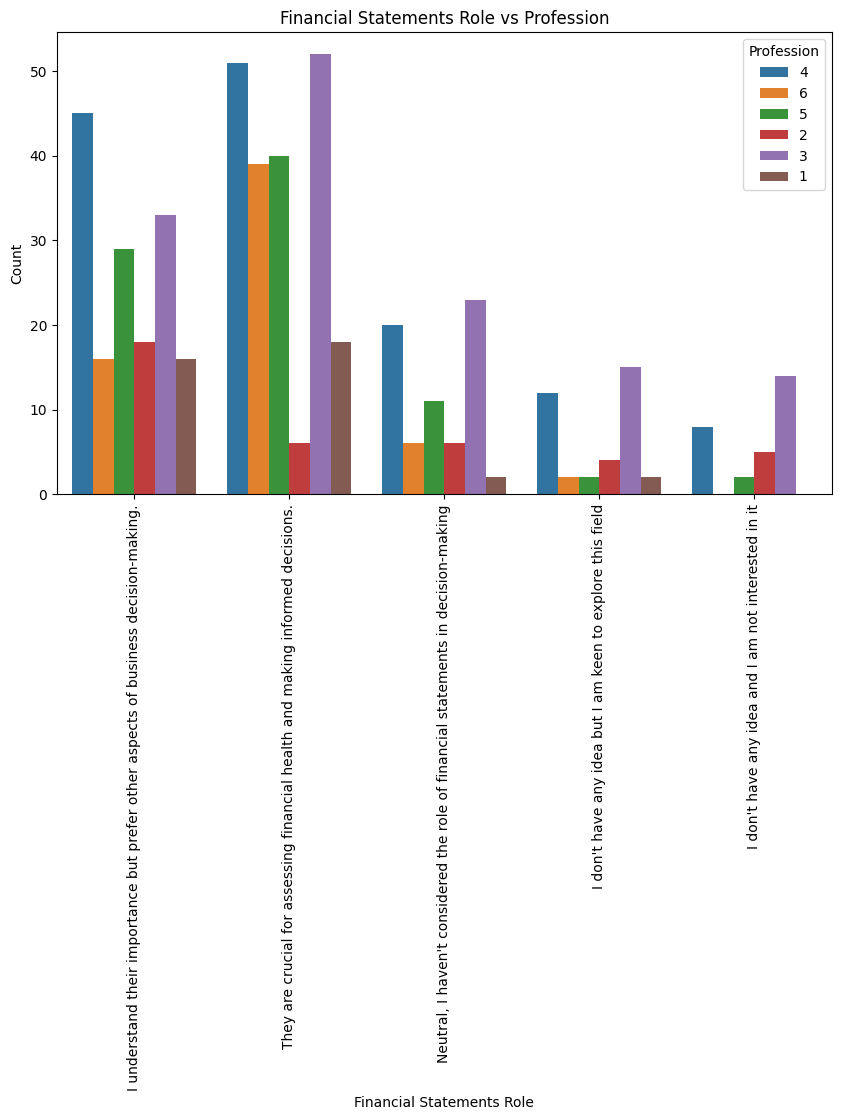

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Loop through each column from the 3rd to the second-to-last column
for column in df.columns[:-1]:
    if column == 'Skills Strengths':
        continue
    plt.figure(figsize=(10, 6))
    
    # Use hue as the actual data of the last column
    sns.countplot(data=df, x=column,hue = "Profession")
    
    plt.title(f'{column} vs {df.columns[-1]}')  # Set title with the last column's name
    plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
    plt.xlabel(column)  # Set x-axis label
    plt.ylabel('Count')  # Set y-axis label
    plt.show()


## Having some more insights of data

## Some count Plots

### Age VS Gender

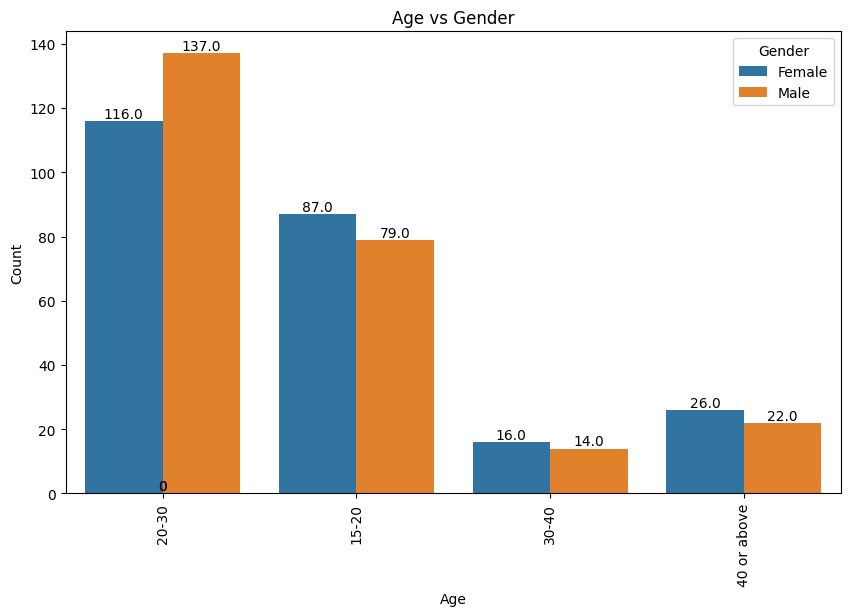

In [21]:
plt.figure(figsize=(10, 6))
cnt = sns.countplot(data=df, x='Age', hue='Gender')

# Add a title and labels
plt.title('Age vs Gender')
plt.xticks(rotation=90)
plt.xlabel('Age')
plt.ylabel('Count')

# Add counts on top of bars
for p in cnt.patches:
    height = p.get_height()
    cnt.annotate(f'{height}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', 
                xytext=(0, 5),  # 5 points vertical offset
                textcoords='offset points')

plt.show()


### Age VS Technology Intererst

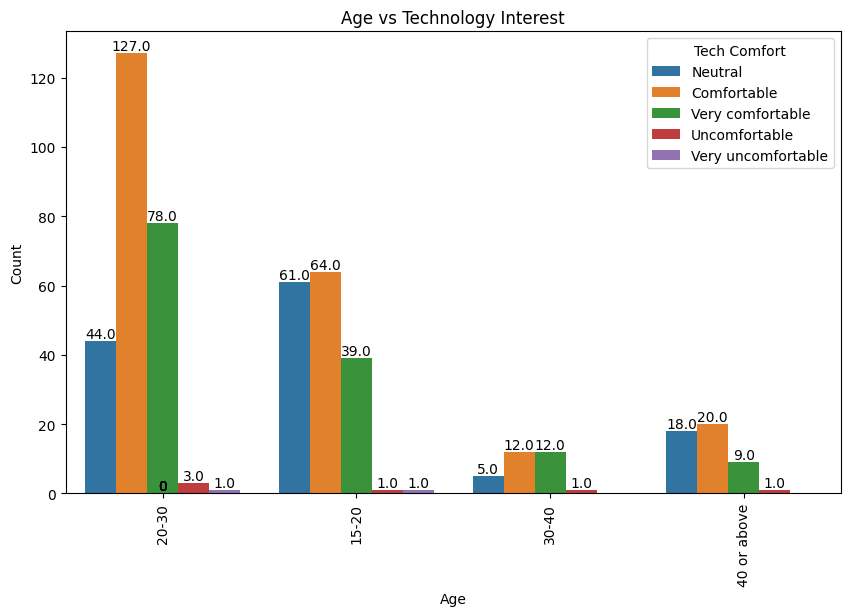

In [22]:
plt.figure(figsize=(10, 6))
cnt = sns.countplot(data=df, x='Age', hue='Tech Comfort') 
plt.title('Age vs Technology Interest')
plt.xticks(rotation=90)  
plt.xlabel('Age')  
plt.ylabel('Count') 
for p in cnt.patches:
    height = p.get_height()
    cnt.annotate(f'{height}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points')
plt.show()

### Gender Vs Technology Interest

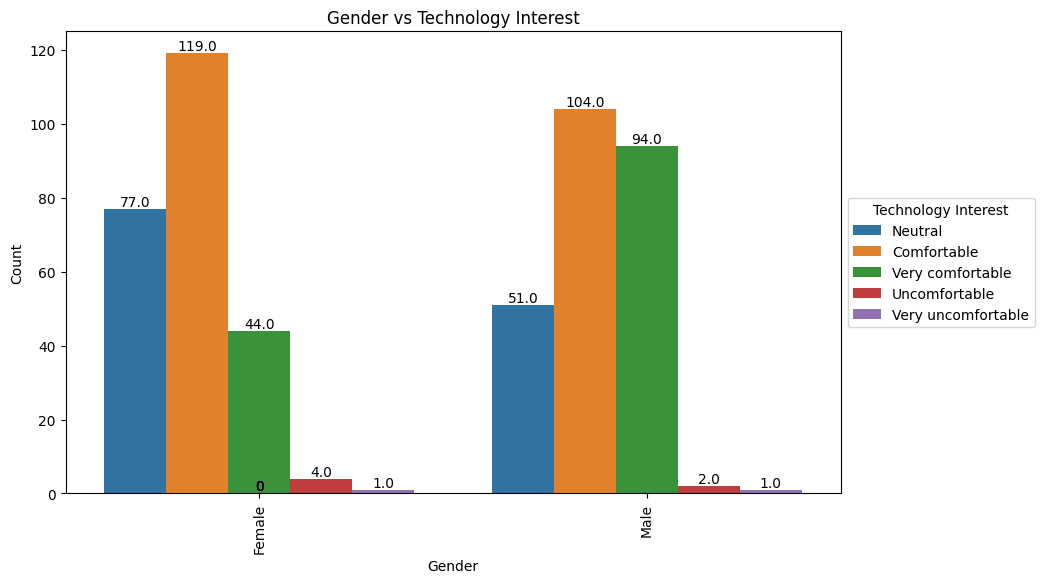

In [23]:
plt.figure(figsize=(10, 6))
cnt = sns.countplot(data=df, x='Gender', hue='Tech Comfort') 
plt.title('Gender vs Technology Interest') 
plt.xticks(rotation=90) 
plt.xlabel('Gender') 
plt.ylabel('Count')
plt.legend(title='Technology Interest', loc='center left', bbox_to_anchor=(1, 0.5))

for p in cnt.patches:
    height = p.get_height()
    cnt.annotate(f'{height}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points')

plt.show()

### Age Vs Programming Interest

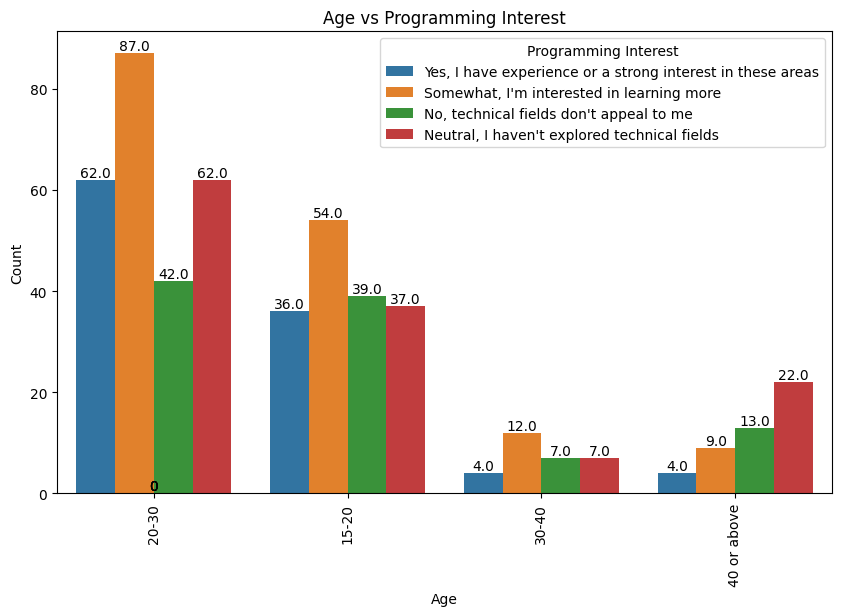

In [24]:
plt.figure(figsize=(10, 6))
cnt = sns.countplot(data=df, x='Age', hue='Programming Interest') 
plt.title('Age vs Programming Interest') 
plt.xticks(rotation=90) 
plt.xlabel('Age') 
plt.ylabel('Count')  

for p in cnt.patches:
    height = p.get_height()
    cnt.annotate(f'{height}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points')

plt.show()

### Gender Vs Programming Interest 

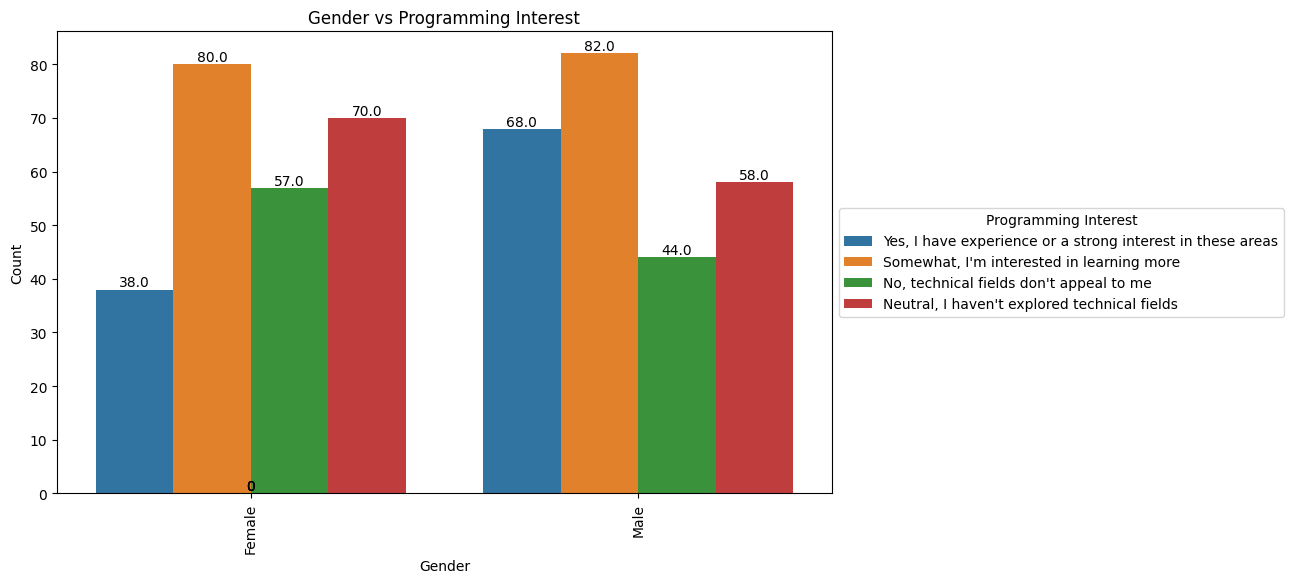

In [25]:
plt.figure(figsize=(10, 6))
cnt = sns.countplot(data=df, x='Gender', hue='Programming Interest') 
plt.title('Gender vs Programming Interest') 
plt.xticks(rotation=90) 
plt.xlabel('Gender') 
plt.ylabel('Count')
plt.legend(title='Programming Interest', loc='center left', bbox_to_anchor=(1, 0.5))

for p in cnt.patches:
    height = p.get_height()
    cnt.annotate(f'{height}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points')

plt.show()

### Age vs Entrepreneurship Interest

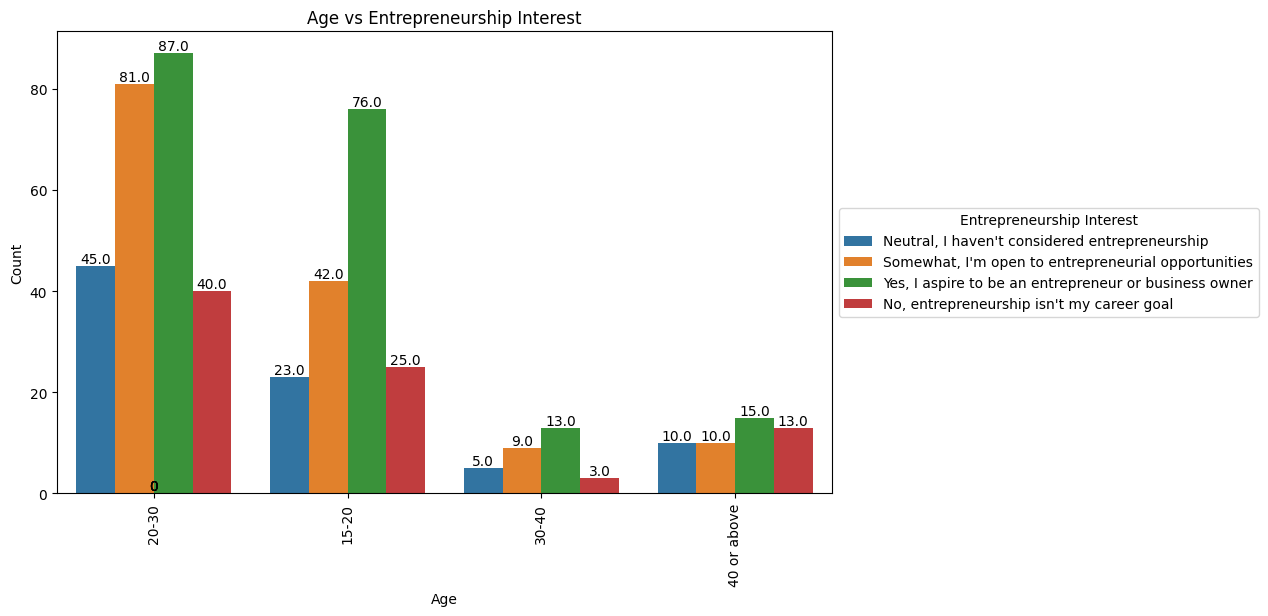

In [26]:
plt.figure(figsize=(10, 6))
cnt = sns.countplot(data=df, x='Age', hue='Entrepreneurship Interest') 
plt.title('Age vs Entrepreneurship Interest') 
plt.xticks(rotation=90) 
plt.xlabel('Age') 
plt.ylabel('Count')
plt.legend(title='Entrepreneurship Interest', loc='center left', bbox_to_anchor=(1, 0.5))

for p in cnt.patches:
    height = p.get_height()
    cnt.annotate(f'{height}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points')

plt.show()

### Gender vs Entrepreneurship Interest

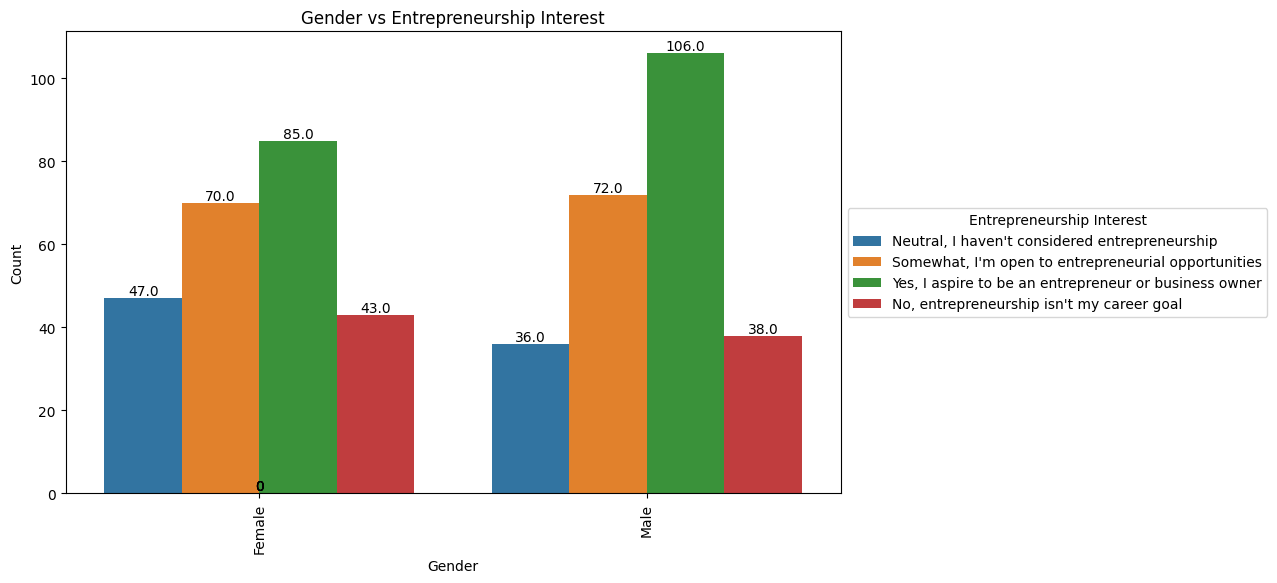

In [27]:
plt.figure(figsize=(10, 6))
cnt = sns.countplot(data=df, x='Gender', hue='Entrepreneurship Interest') 
plt.title('Gender vs Entrepreneurship Interest') 
plt.xticks(rotation=90) 
plt.xlabel('Gender') 
plt.ylabel('Count')
plt.legend(title='Entrepreneurship Interest', loc='center left', bbox_to_anchor=(1, 0.5))

for p in cnt.patches:
    height = p.get_height()
    cnt.annotate(f'{height}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points')

plt.show()

### Age Vs Public Services

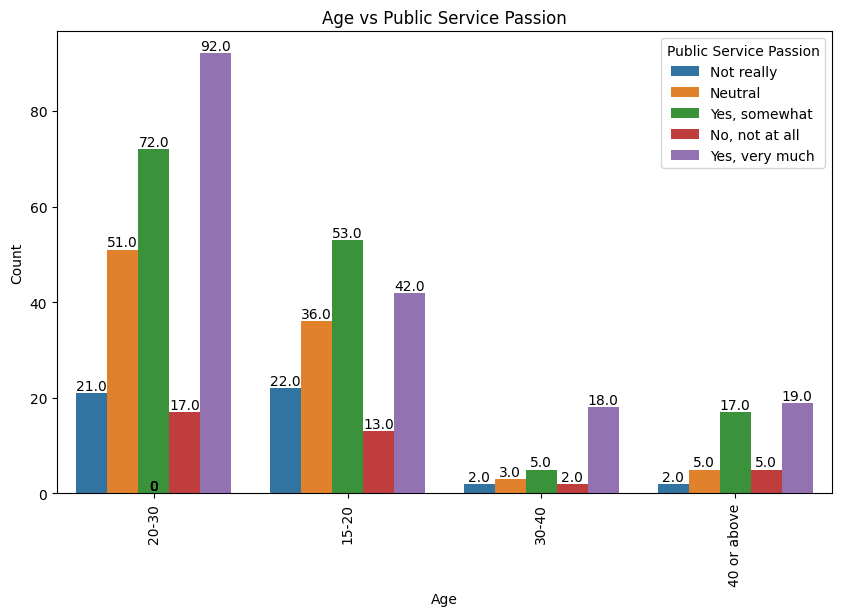

In [28]:
plt.figure(figsize=(10, 6))
cnt = sns.countplot(data=df, x='Age', hue='Public Service Passion') 
plt.title('Age vs Public Service Passion') 
plt.xticks(rotation=90) 
plt.xlabel('Age') 
plt.ylabel('Count')  

for p in cnt.patches:
    height = p.get_height()
    cnt.annotate(f'{height}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points')

plt.show()

### Gender Vs Public Services

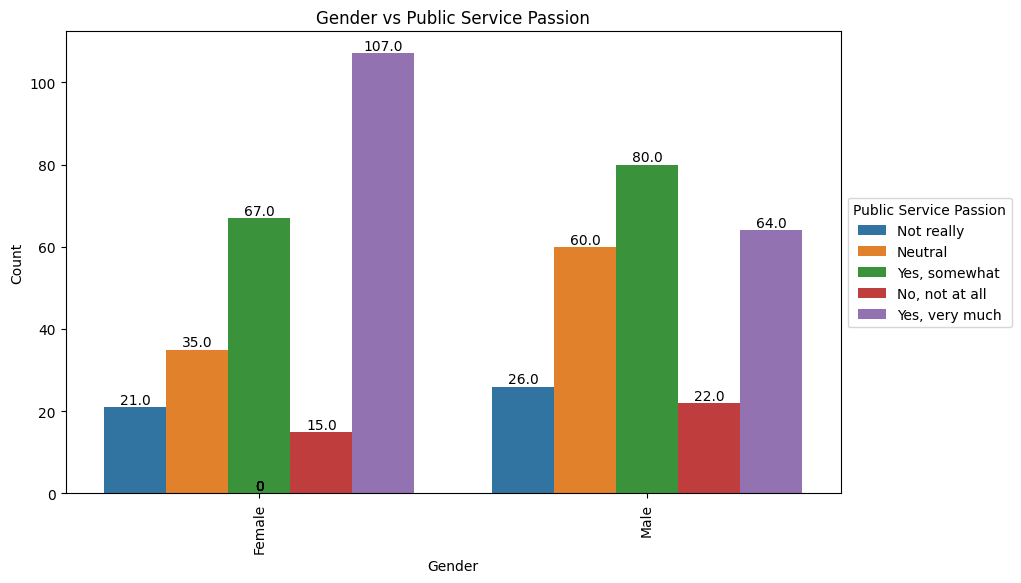

In [29]:
plt.figure(figsize=(10, 6))
cnt = sns.countplot(data=df, x='Gender', hue='Public Service Passion')  
plt.title('Gender vs Public Service Passion')  
plt.xticks(rotation=90)
plt.xlabel('Gender') 
plt.ylabel('Count')
plt.legend(title='Public Service Passion', loc='center left', bbox_to_anchor=(1, 0.5))

for p in cnt.patches:
    height = p.get_height()
    cnt.annotate(f'{height}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points')

plt.show()

### Age vs Knowledge Sharing

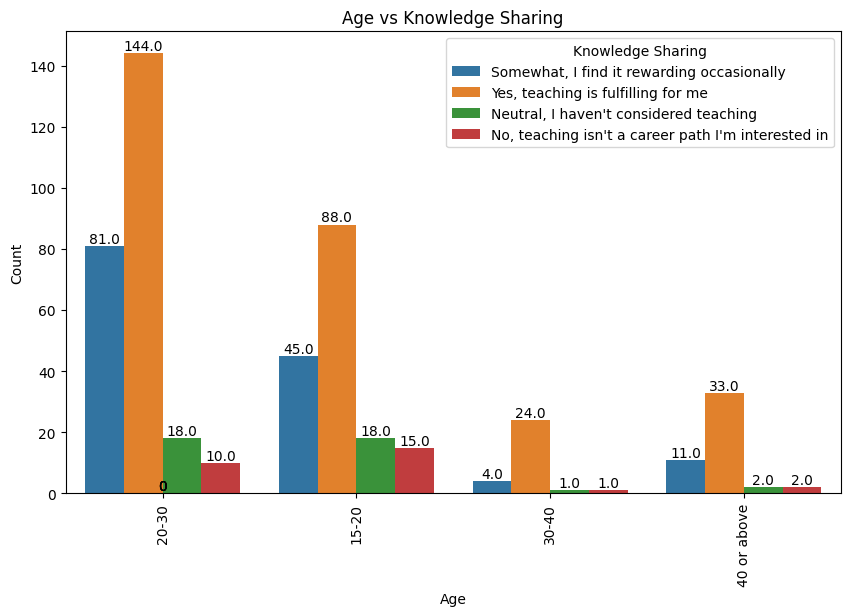

In [30]:
plt.figure(figsize=(10, 6))
cnt = sns.countplot(data=df, x='Age', hue='Knowledge Sharing') 
plt.title('Age vs Knowledge Sharing')  
plt.xticks(rotation=90)  
plt.xlabel('Age')  
plt.ylabel('Count')

for p in cnt.patches:
    height = p.get_height()
    cnt.annotate(f'{height}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points')

plt.show()

### Gender Vs Knowledge Sharing

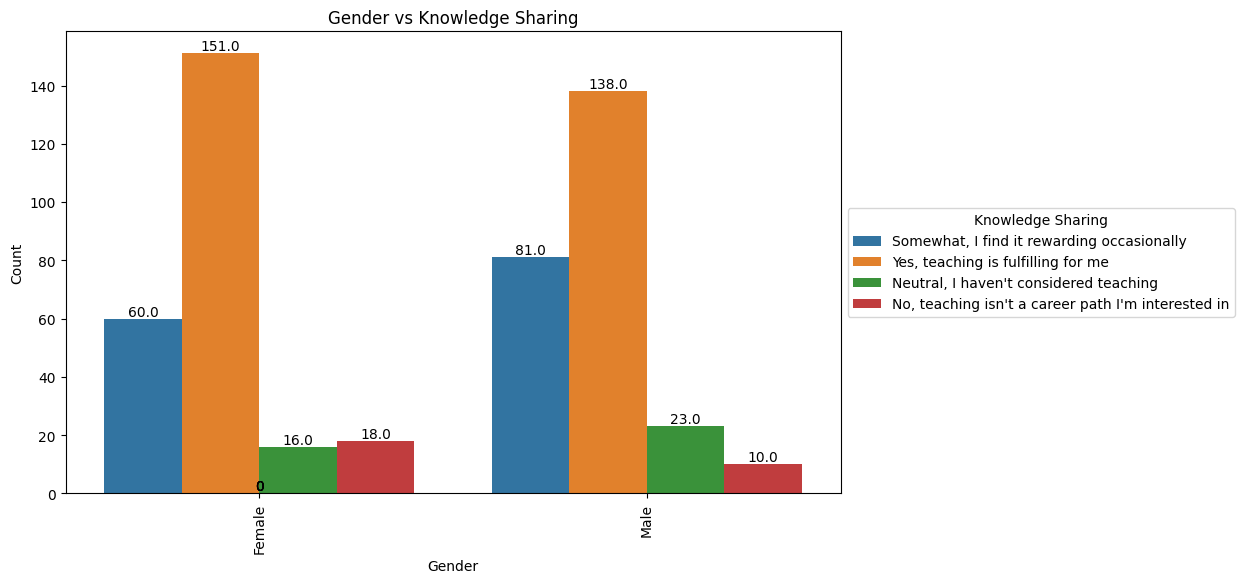

In [31]:
plt.figure(figsize=(10, 6))
cnt = sns.countplot(data=df, x='Gender', hue='Knowledge Sharing')  
plt.title('Gender vs Knowledge Sharing')
plt.xticks(rotation=90) 
plt.xlabel('Gender')  
plt.ylabel('Count')
plt.legend(title='Knowledge Sharing', loc='center left', bbox_to_anchor=(1, 0.5))

for p in cnt.patches:
    height = p.get_height()
    cnt.annotate(f'{height}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points')

plt.show()

### Age Vs Medical Interest

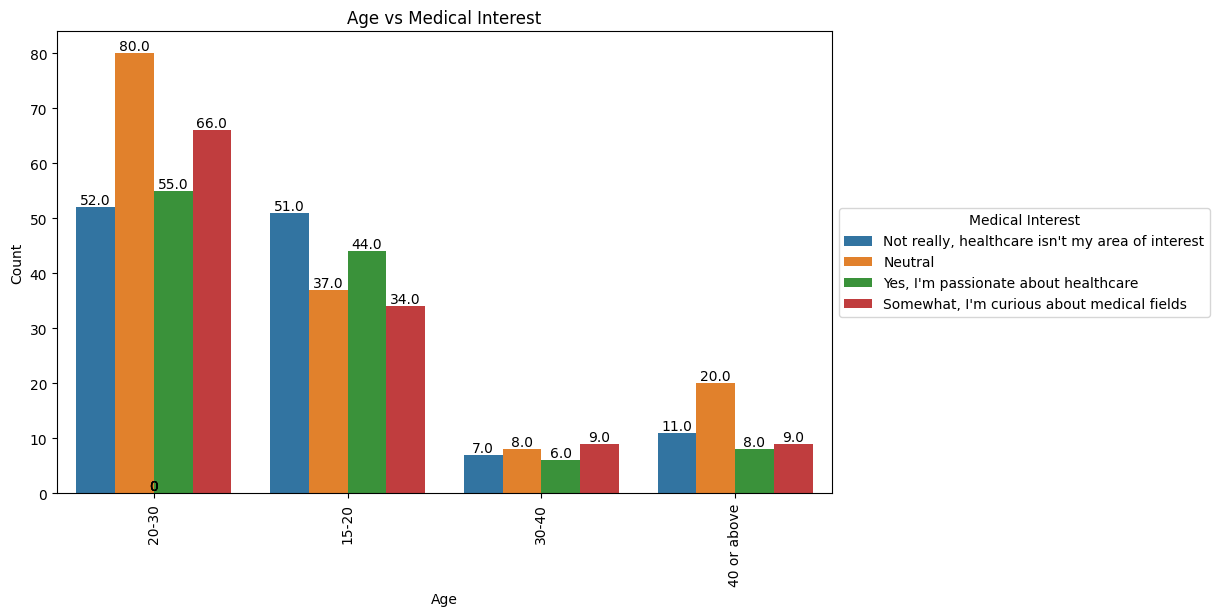

In [32]:
plt.figure(figsize=(10, 6))
cnt = sns.countplot(data=df, x='Age', hue='Medical Interest') 
plt.title('Age vs Medical Interest')  
plt.xticks(rotation=90)  
plt.xlabel('Age')  
plt.ylabel('Count')
plt.legend(title='Medical Interest', loc='center left', bbox_to_anchor=(1, 0.5))

for p in cnt.patches:
    height = p.get_height()
    cnt.annotate(f'{height}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points')

plt.show()

### Gender Vs Medical Interest

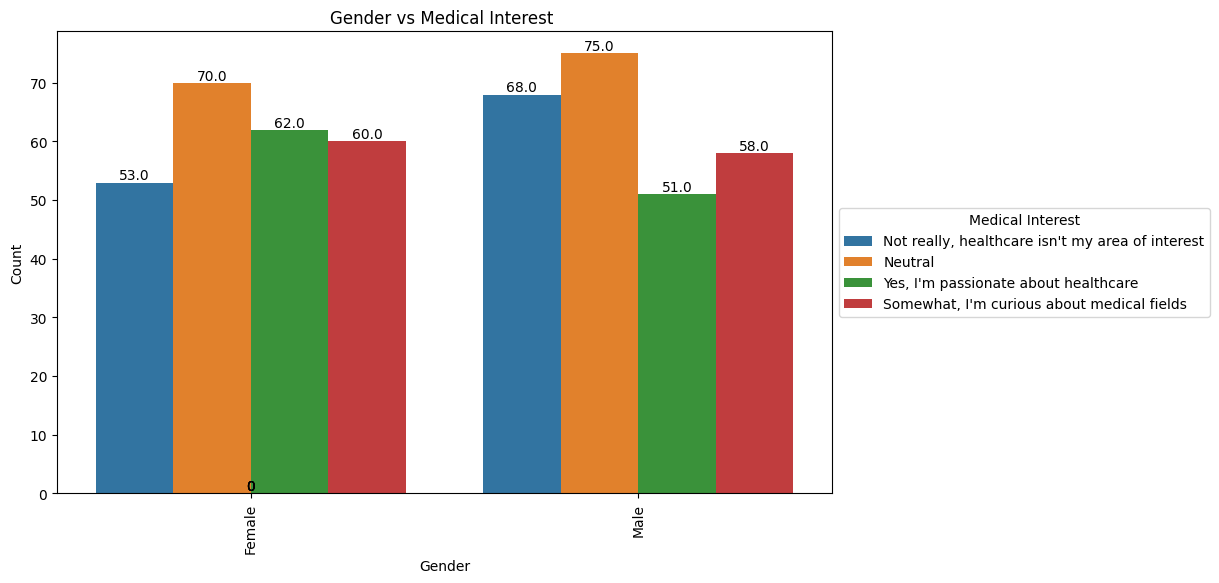

In [33]:
plt.figure(figsize=(10, 6))
cnt = sns.countplot(data=df, x='Gender', hue='Medical Interest')  
plt.title('Gender vs Medical Interest ')
plt.xticks(rotation=90) 
plt.xlabel('Gender')  
plt.ylabel('Count')
plt.legend(title='Medical Interest', loc='center left', bbox_to_anchor=(1, 0.5))

for p in cnt.patches:
    height = p.get_height()
    cnt.annotate(f'{height}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points')

plt.show()

### Age vs Market Trends Interest

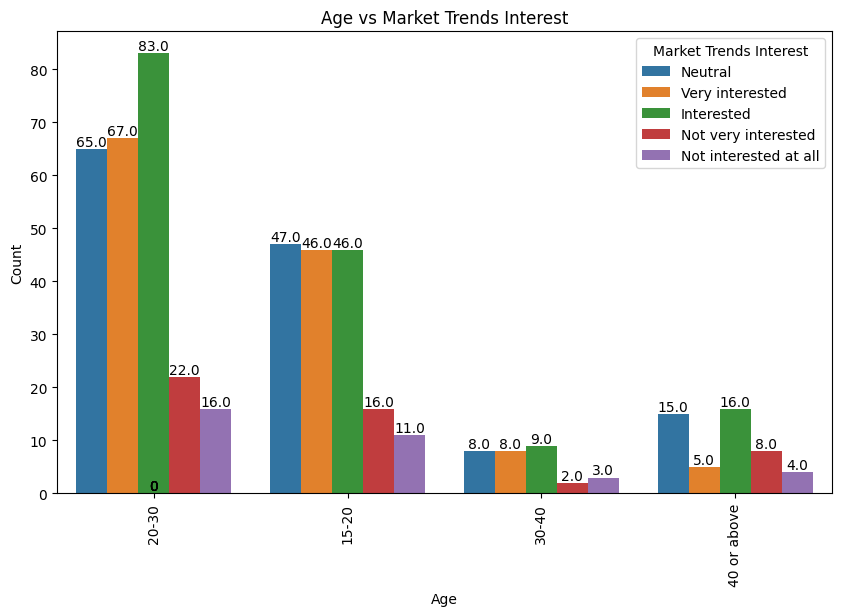

In [34]:
plt.figure(figsize=(10, 6))
cnt = sns.countplot(data=df, x='Age', hue='Market Trends Interest') 
plt.title('Age vs Market Trends Interest')  
plt.xticks(rotation=90)  
plt.xlabel('Age')  
plt.ylabel('Count')

for p in cnt.patches:
    height = p.get_height()
    cnt.annotate(f'{height}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points')

plt.show()

### Gender Vs Market Trends Interest 

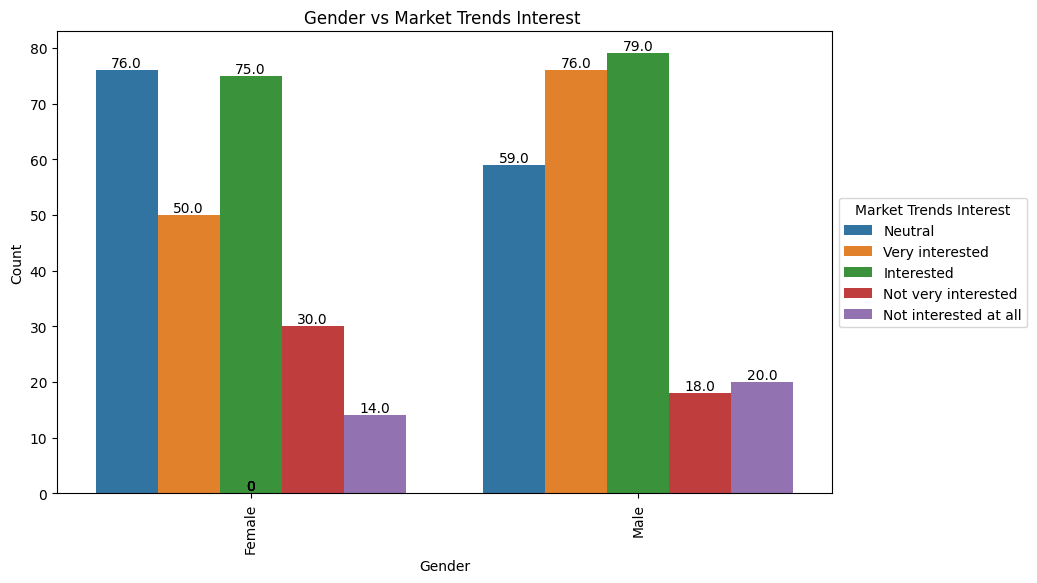

In [35]:
plt.figure(figsize=(10, 6))
cnt = sns.countplot(data=df, x='Gender', hue='Market Trends Interest')  
plt.title('Gender vs Market Trends Interest ')
plt.xticks(rotation=90) 
plt.xlabel('Gender')  
plt.ylabel('Count') 
plt.legend(title='Market Trends Interest', loc='center left', bbox_to_anchor=(1, 0.5))

for p in cnt.patches:
    height = p.get_height()
    cnt.annotate(f'{height}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points')

plt.show()

### Age Vs Sports Passion

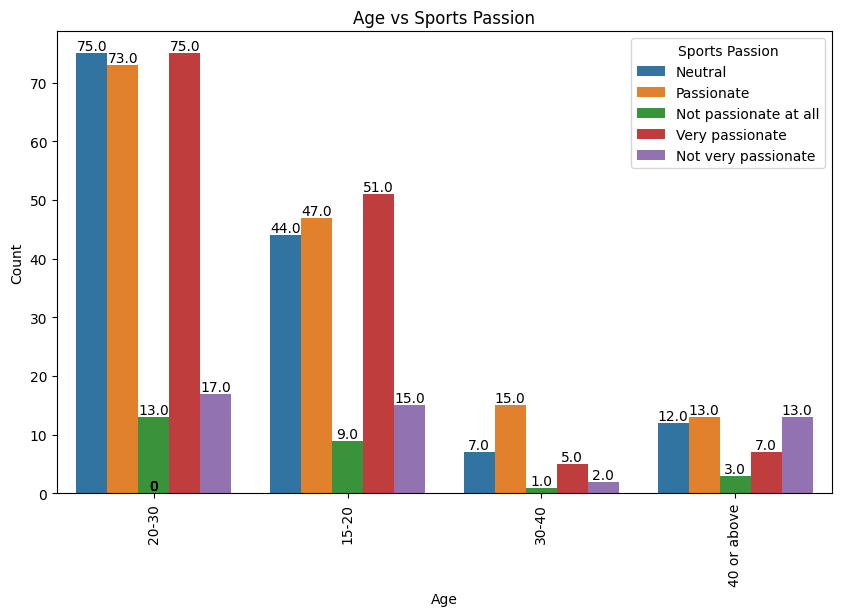

In [36]:
plt.figure(figsize=(10, 6))
cnt = sns.countplot(data=df, x='Age', hue='Sports Passion')  
plt.title('Age vs Sports Passion')  
plt.xticks(rotation=90) 
plt.xlabel('Age') 
plt.ylabel('Count')

for p in cnt.patches:
    height = p.get_height()
    cnt.annotate(f'{height}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points')

plt.show()

### Gender Vs Sports Passion

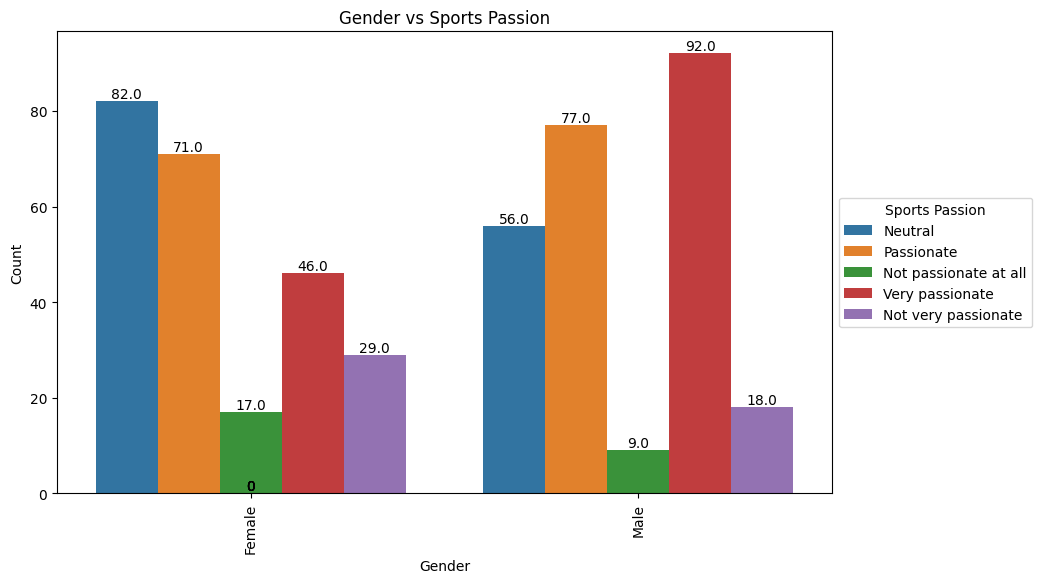

In [37]:
plt.figure(figsize=(10, 6))
cnt = sns.countplot(data=df, x='Gender', hue='Sports Passion')  
plt.title('Gender vs Sports Passion')  
plt.xticks(rotation=90)
plt.xlabel('Gender')  
plt.ylabel('Count')  
plt.legend(title='Sports Passion', loc='center left', bbox_to_anchor=(1, 0.5))

for p in cnt.patches:
    height = p.get_height()
    cnt.annotate(f'{height}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points')

plt.show()

### Age Vs Educational Interest

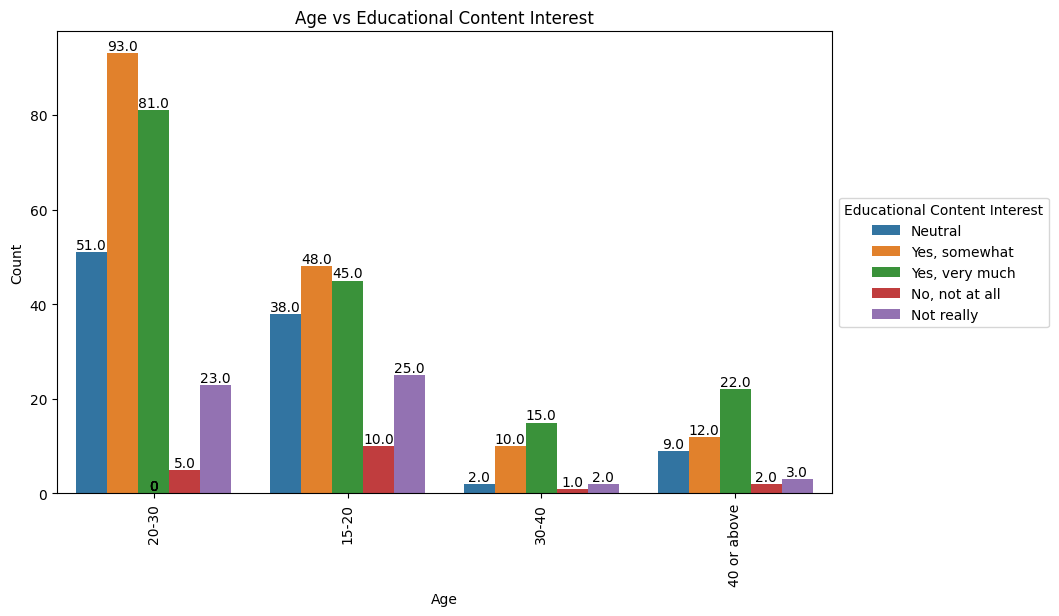

In [38]:
plt.figure(figsize=(10, 6))
cnt = sns.countplot(data=df, x='Age', hue='Educational Content Interest') 
plt.title('Age vs Educational Content Interest') 
plt.xticks(rotation=90) 
plt.xlabel('Age') 
plt.ylabel('Count') 
plt.legend(title='Educational Content Interest', loc='center left', bbox_to_anchor=(1, 0.5))

for p in cnt.patches:
    height = p.get_height()
    cnt.annotate(f'{height}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points')

plt.show()

### Gender Vs Educational Interest

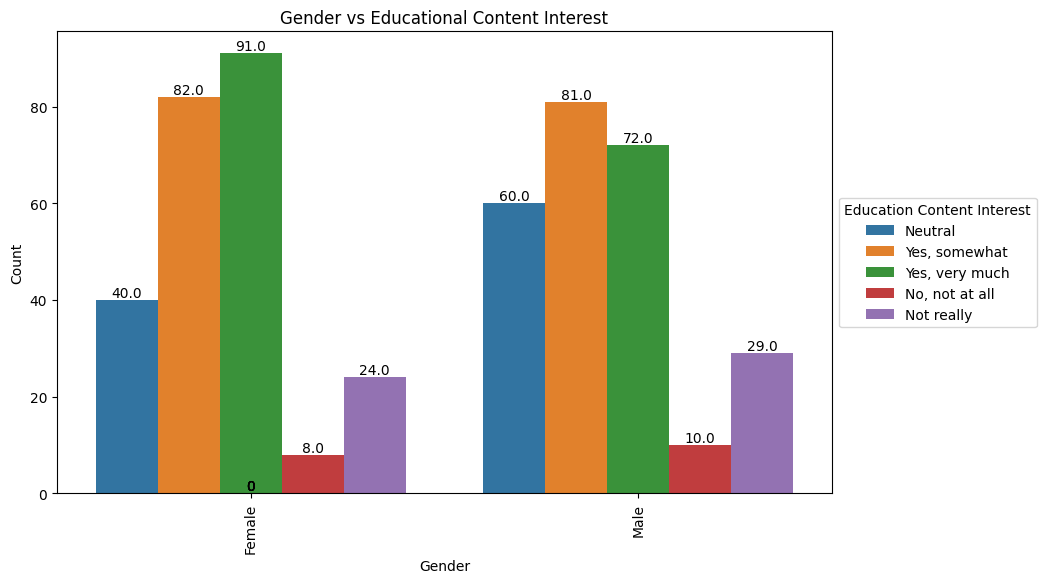

In [39]:
plt.figure(figsize=(10, 6))
cnt = sns.countplot(data=df, x='Gender', hue='Educational Content Interest')  # Use hue to color by Gender
plt.title('Gender vs Educational Content Interest')  # Set title
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.xlabel('Gender')  # Set x-axis label
plt.ylabel('Count')  # Set y-axis label
plt.legend(title='Education Content Interest', loc='center left', bbox_to_anchor=(1, 0.5))

for p in cnt.patches:
    height = p.get_height()
    cnt.annotate(f'{height}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points')

plt.show()

### Age Vs Financial Interest

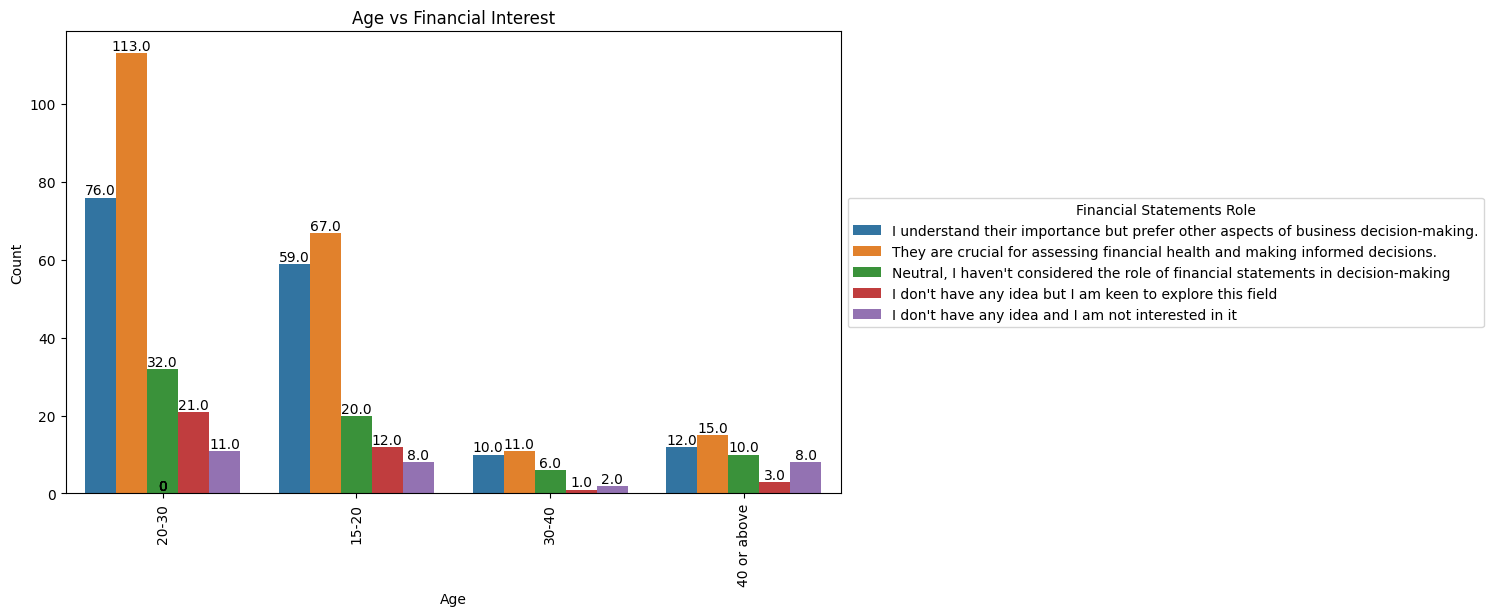

In [40]:
plt.figure(figsize=(10, 6))
cnt = sns.countplot(data=df, x='Age', hue='Financial Statements Role')  # Use hue to color by Gender
plt.title('Age vs Financial Interest')  # Set title
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.xlabel('Age')  # Set x-axis label
plt.ylabel('Count')  # Set y-axis label
plt.legend(title='Financial Statements Role', loc='center left', bbox_to_anchor=(1, 0.5))

for p in cnt.patches:
    height = p.get_height()
    cnt.annotate(f'{height}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points')

plt.show()

### Gender Vs Financial Interest

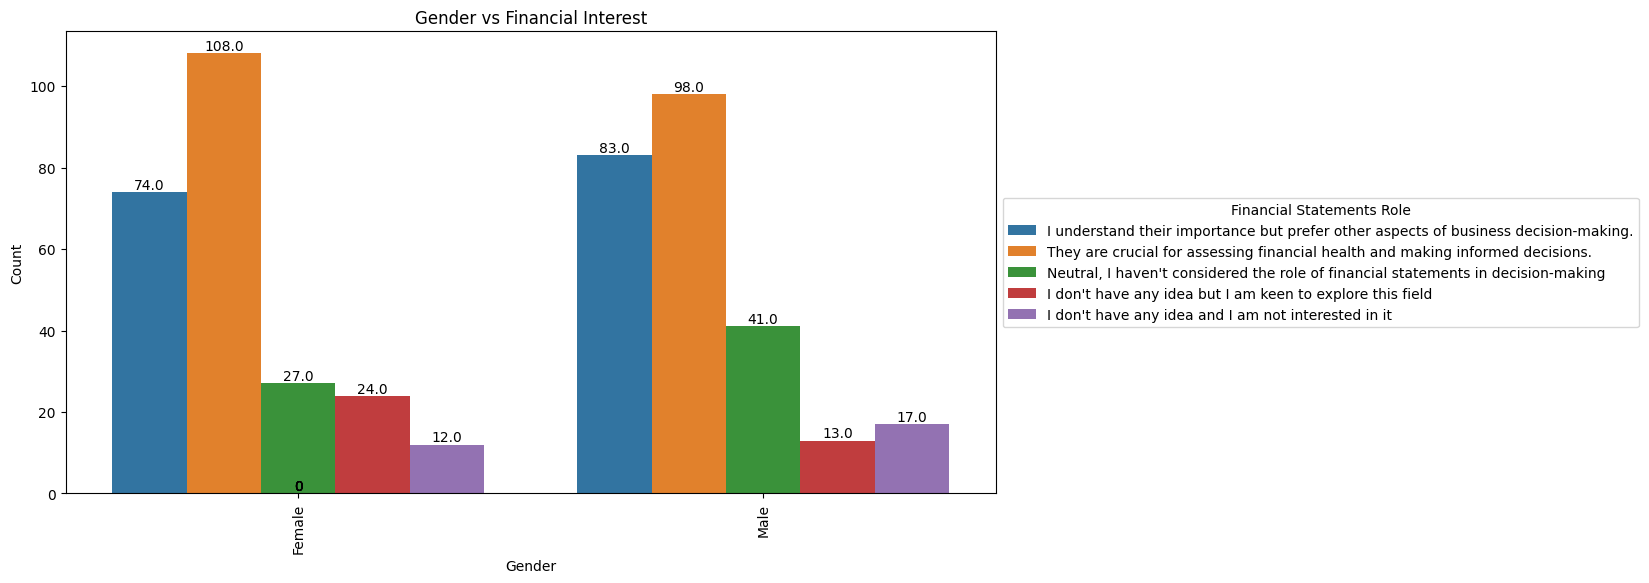

In [41]:
plt.figure(figsize=(12, 6))
cnt= sns.countplot(data=df, x='Gender', hue='Financial Statements Role')  
plt.title('Gender vs Financial Interest')  # Set title
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.xlabel('Gender')  # Set x-axis label
plt.ylabel('Count')  # Set y-axis label

# Move the legend to the right side
plt.legend(title='Financial Statements Role', loc='center left', bbox_to_anchor=(1, 0.5))

for p in cnt.patches:
    height = p.get_height()
    cnt.annotate(f'{height}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points')
plt.show()


## We will do Ordinal Encoding

Let's apply OHE on all the columns Encoding 

## Train Test Split

In [42]:
from sklearn.model_selection import train_test_split

X = df.drop('Profession', axis=1)
y = df['Profession']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=52)




In [43]:
X_train

,Age,Gender,Free Time Activity,Work Environment,Tech Comfort,JobSecurity Importance,Artistic Expression Importance,Physical Fitness Importance,Financial Analysis Approach,Programming Interest,...,Helping Others Desire,Medical Interest,Market Trends Interest,Sports Management Interest,Sports Passion,Finance Management Interest,Technology Curiosity,Educational Content Interest,Fashion Interest,Financial Statements Role
231,15-20,Female,Playing sports with your friends.,Remote/Work from home,Very comfortable,Very important,"Very important, it's a significant part of who...","Very important, I prioritize fitness and health",Not interested in this,"Yes, I have experience or a strong interest in...",...,Neutral,"Yes, I'm passionate about healthcare",Interested,"Neutral, I'm unsure",Passionate,Not really,"Somewhat, I'm curious to learn more",Neutral,Neutral,I understand their importance but prefer other...
388,20-30,Female,Lying on your couch and watching Netflix.,Studio/Workshop,Very comfortable,Very important,"Essential, I thrive on creativity","Moderately important, I enjoy physical activit...","Neutral, I haven't had much experience in fina...","No, technical fields don't appeal to me",...,"Yes, caring for others is important to me",Neutral,Not interested at all,"Neutral, I'm unsure",Neutral,Neutral,Neutral,Neutral,Neutral,I understand their importance but prefer other...
149,20-30,Female,Lying on your couch and watching Netflix.,Office setting,Comfortable,Very important,"Moderately important, I enjoy creative pursuits","Important, I try to stay active regularly","Neutral, I haven't had much experience in fina...","No, technical fields don't appeal to me",...,"Yes, caring for others is important to me","Yes, I'm passionate about healthcare",Very interested,"Yes, I enjoy coaching and organizing sports ac...",Very passionate,"Yes, very much","Yes, I'm interested in these fields","Yes, very much","Yes, very much",They are crucial for assessing financial healt...
370,20-30,Female,Reading a book in the garden during summer.,Laboratory,Very comfortable,Important,"Moderately important, I enjoy creative pursuits","Very important, I prioritize fitness and health","Neutral, I haven't had much experience in fina...","Somewhat, I'm interested in learning more",...,"Yes, caring for others is important to me","Not really, healthcare isn't my area of interest",Not interested at all,"Neutral, I'm unsure",Not passionate at all,"No, not at all","Yes, I'm interested in these fields","Yes, somewhat","No, not at all",I don't have any idea but I am keen to explore...
295,15-20,Female,Lying on your couch and watching Netflix.,Remote/Work from home,Comfortable,Very important,"Moderately important, I enjoy creative pursuits","Very important, I prioritize fitness and health",I enjoy analyzing financial reports and making...,"Yes, I have experience or a strong interest in...",...,"Yes, caring for others is important to me","Yes, I'm passionate about healthcare",Neutral,"Neutral, I'm unsure",Passionate,"Yes, somewhat","Somewhat, I'm curious to learn more","Yes, somewhat","Yes, very much",I don't have any idea but I am keen to explore...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,40 or above,Male,Lying on your couch and watching Netflix.,Remote/Work from home,Neutral,Important,"Very important, it's a significant part of who...","Moderately important, I enjoy physical activit...",I can perform financial analysis tasks but pre...,"Neutral, I haven't explored technical fields",...,"Somewhat, I'm interested in healthcare",Neutral,Interested,"Somewhat, I might consider it",Passionate,"Yes, somewhat",Neutral,Neutral,"Yes, somewhat",I understand their importance but prefer other...
151,20-30,Male,Playing sports with your friends.,Studio/Workshop,Neutral,Neutral,"Very important, it's a significant part of who...","Important, I try to stay active regularly",I enjoy analyzing financial reports and making...,"Neutral, I h

In [44]:
X_train.shape

(397, 29)

In [45]:
X_test

,Age,Gender,Free Time Activity,Work Environment,Tech Comfort,JobSecurity Importance,Artistic Expression Importance,Physical Fitness Importance,Financial Analysis Approach,Programming Interest,...,Helping Others Desire,Medical Interest,Market Trends Interest,Sports Management Interest,Sports Passion,Finance Management Interest,Technology Curiosity,Educational Content Interest,Fashion Interest,Financial Statements Role
136,20-30,Male,Reading a book in the garden during summer.,Laboratory,Very comfortable,Neutral,"Not important at all, I focus on other aspects...","Very important, I prioritize fitness and health",I enjoy analyzing financial reports and making...,"Somewhat, I'm interested in learning more",...,"Yes, caring for others is important to me","Not really, healthcare isn't my area of interest",Very interested,"Yes, I enjoy coaching and organizing sports ac...",Very passionate,"Yes, very much","Yes, I'm interested in these fields",Neutral,"No, not at all",They are crucial for assessing financial healt...
323,15-20,Male,Playing sports with your friends.,Remote/Work from home,Neutral,Very important,"Not very important, I prefer practical tasks","Very important, I prioritize fitness and health",I can perform financial analysis tasks but pre...,"No, technical fields don't appeal to me",...,Neutral,Neutral,Very interested,"No, I prefer participating rather than organizing",Passionate,"Yes, very much","Somewhat, I'm curious to learn more",Neutral,Not really,I understand their importance but prefer other...
438,40 or above,Female,Embracing your artistic skills by painting or ...,Laboratory,Uncomfortable,Very important,"Essential, I thrive on creativity","Very important, I prioritize fitness and health",I enjoy analyzing financial reports and making...,"Neutral, I haven't explored technical fields",...,"Yes, caring for others is important to me",Neutral,Neutral,"Somewhat, I might consider it",Passionate,Neutral,"Somewhat, I'm curious to learn more","Yes, very much",Neutral,They are crucial for assessing financial healt...
207,20-30,Female,Developing your skills in trading or learning ...,Remote/Work from home,Comfortable,Important,"Moderately important, I enjoy creative pursuits","Moderately important, I enjoy physical activit...","Neutral, I haven't had much experience in fina...","Somewhat, I'm interested in learning more",...,"Yes, caring for others is important to me","Somewhat, I'm curious about medical fields",Interested,"Neutral, I'm unsure",Neutral,"Yes, somewhat","Somewhat, I'm curious to learn more",Neutral,Neutral,I understand their importance but prefer other...
454,20-30,Male,Writing and developing programming codes.,Remote/Work from home,Comfortable,Very important,"Moderately important, I enjoy creative pursuits","Moderately important, I enjoy physical activit...",Not interested in this,"Yes, I have experience or a strong interest in...",...,"Yes, caring for others is important to me",Neutral,Neutral,"Neutral, I'm unsure",Neutral,Neutral,Neutral,"Yes, very much","Yes, somewhat",I don't have any idea but I am keen to explore...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198,20-30,Female,Lying on your couch and watching Netflix.,Remote/Work from home,Very comfortable,Important,"Moderately important, I enjoy creative pursuits","Moderately important, I enjoy physical activit...","Neutral, I haven't had much experience in fina...","Somewhat, I'm interested in learning more",...,"Yes, caring for others is important to me","Not really, healthcare isn't my area of interest",Interested,"Somewhat, I might consider it",Not very passionate,"Yes, somewhat","Somewhat, I'm curious to learn more","Yes, very much","Yes, very much",They are crucial for assessing financial healt...
402,30-40,Male,Lying on your couch and watching Netflix.,Studio/Workshop,Very comfortable,Important,"Essential, I thrive on creativity","Moderately important, I enjoy physical activit...","Neutral, I haven't had 

## Encoding

In [46]:
encoder = OrdinalEncoder()

In [47]:
# Apply ordinal encoding
X_train = encoder.fit_transform(X_train)
X_test = encoder.transform(X_test)


In [48]:
X_train

array([[0., 0., 3., ..., 0., 0., 2.],
       [1., 0., 2., ..., 0., 0., 2.],
       [1., 0., 2., ..., 4., 4., 4.],
       ...,
       [1., 1., 3., ..., 4., 2., 4.],
       [0., 0., 4., ..., 4., 2., 1.],
       [1., 0., 1., ..., 3., 4., 4.]])

In [49]:
X_train.shape

(397, 29)

In [50]:
X_test

array([[1., 1., 4., ..., 0., 1., 4.],
       [0., 1., 3., ..., 0., 2., 2.],
       [3., 0., 1., ..., 4., 0., 4.],
       ...,
       [3., 1., 3., ..., 4., 4., 3.],
       [1., 1., 6., ..., 4., 0., 2.],
       [0., 1., 3., ..., 3., 1., 3.]])

In [51]:
X_train.shape

(397, 29)

In [52]:
#print(X_train.dtypes)


In [53]:
X_train.shape

(397, 29)

## Label Encoding 

In [54]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le = LabelEncoder()

# Fit and transform the target labels
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Verify the classes
print("Classes:", le.classes_)


Classes: ['1' '2' '3' '4' '5' '6']


In [55]:
#X_train = X_train_transformed
#X_test = X_test_transformed
print(X_train.shape)
print(y_train.shape)

(397, 29)
(397,)


## Training Model

In [56]:
def evaluate_model(true, predicted):
    accuracy = accuracy_score(true, predicted)
    recall = recall_score(true, predicted, average='weighted')
    precision = precision_score(true, predicted, average='weighted')
    f1 = f1_score(true, predicted, average='weighted')
    return accuracy, recall, precision, f1

In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'AdaBoost': AdaBoostClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'XGBoost': XGBClassifier(random_state=42),
    'SVM': SVC(random_state=42),
}

# Define hyperparameter grids
param_grids = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear']
    },
    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5, 10],
    },
    'Decision Tree': {
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
    },
    'K-Nearest Neighbors': {
        'n_neighbors': [3, 5, 7, 9],
        'weights': ['uniform', 'distance'],
        'p': [1, 2],
    },
    'AdaBoost': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 1, 10],
    },
    'Gradient Boosting': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 1],
        'max_depth': [3, 5, 7],
    },
    'XGBoost': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 1],
        'max_depth': [3, 5, 7],
    },
    'SVM': {
        'C': [0.1, 1, 10],
        'kernel': ['linear', 'rbf'],
        'gamma': ['scale', 'auto'],
    },
}


In [58]:
from sklearn.model_selection import GridSearchCV

# Store the best models after tuning
best_models = {}

# Perform Grid Search
for model_name, model in models.items():
    print(f"Tuning {model_name}...")
    param_grid = param_grids[model_name]
    grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
    
    grid_search.fit(X_train, y_train_encoded)
    
    best_models[model_name] = grid_search.best_estimator_
    print(f"Best parameters for {model_name}: {grid_search.best_params_}\n")


Tuning Logistic Regression...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters for Logistic Regression: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}

Tuning Random Forest...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters for Random Forest: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}

Tuning Decision Tree...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters for Decision Tree: {'max_depth': 10, 'min_samples_split': 10}

Tuning K-Nearest Neighbors...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters for K-Nearest Neighbors: {'n_neighbors': 9, 'p': 2, 'weights': 'distance'}

Tuning AdaBoost...
Fitting 5 folds for each of 12 candidates, totalling 60 fits


C:\Users\dell\anaconda3\Anaconda\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Best parameters for AdaBoost: {'learning_rate': 0.1, 'n_estimators': 200}

Tuning Gradient Boosting...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters for Gradient Boosting: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}

Tuning XGBoost...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters for XGBoost: {'learning_rate': 1, 'max_depth': 3, 'n_estimators': 200}

Tuning SVM...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters for SVM: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}



In [59]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

# Function to evaluate model performance
def evaluate_model(true, predicted):
    accuracy = accuracy_score(true, predicted)
    recall = recall_score(true, predicted, average='weighted')
    precision = precision_score(true, predicted, average='weighted')
    f1 = f1_score(true, predicted, average='weighted')
    return accuracy, recall, precision, f1

# Evaluate the best models
for model_name, best_model in best_models.items():
    y_pred = best_model.predict(X_test)
    
    accuracy, recall, precision, f1 = evaluate_model(y_test_encoded, y_pred)
    print(f"Model: {model_name}")
    print(f"Accuracy: {accuracy:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"F1 Score: {f1:.2f}")
    print("\n")


Model: Logistic Regression
Accuracy: 0.42
Recall: 0.42
Precision: 0.44
F1 Score: 0.41


Model: Random Forest
Accuracy: 0.46
Recall: 0.46
Precision: 0.45
F1 Score: 0.42


Model: Decision Tree
Accuracy: 0.32
Recall: 0.32
Precision: 0.31
F1 Score: 0.30




C:\Users\dell\anaconda3\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Model: K-Nearest Neighbors
Accuracy: 0.37
Recall: 0.37
Precision: 0.35
F1 Score: 0.35


Model: AdaBoost
Accuracy: 0.44
Recall: 0.44
Precision: 0.42
F1 Score: 0.42


Model: Gradient Boosting
Accuracy: 0.40
Recall: 0.40
Precision: 0.42
F1 Score: 0.39


Model: XGBoost
Accuracy: 0.41
Recall: 0.41
Precision: 0.42
F1 Score: 0.41


Model: SVM
Accuracy: 0.43
Recall: 0.43
Precision: 0.47
F1 Score: 0.43




C:\Users\dell\anaconda3\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [60]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'AdaBoost': AdaBoostClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'XGBoost': XGBClassifier(random_state=42),
    'SVM':SVC(random_state=42),
}

# Train and evaluate each model
def evaluate_model(true, predicted):
    accuracy = accuracy_score(true, predicted)
    recall = recall_score(true, predicted, average='weighted')
    precision = precision_score(true, predicted, average='weighted')
    f1 = f1_score(true, predicted, average='weighted')
    return accuracy, recall, precision, f1

for model_name, model in models.items():
    
    
    model.fit(X_train, y_train_encoded)
    y_pred = model.predict(X_test)

    accuracy, recall, precision, f1 = evaluate_model(y_test_encoded, y_pred)
    print(f"Model: {model_name}")
    print(f"Accuracy: {accuracy:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"F1 Score: {f1:.2f}")
    print("\n")


Model: Logistic Regression
Accuracy: 0.44
Recall: 0.44
Precision: 0.46
F1 Score: 0.44


Model: Random Forest
Accuracy: 0.46
Recall: 0.46
Precision: 0.45
F1 Score: 0.42




C:\Users\dell\anaconda3\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\dell\anaconda3\Anaconda\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Model: Decision Tree
Accuracy: 0.31
Recall: 0.31
Precision: 0.38
F1 Score: 0.32


Model: K-Nearest Neighbors
Accuracy: 0.36
Recall: 0.36
Precision: 0.36
F1 Score: 0.35


Model: AdaBoost
Accuracy: 0.43
Recall: 0.43
Precision: 0.47
F1 Score: 0.42


Model: Gradient Boosting
Accuracy: 0.45
Recall: 0.45
Precision: 0.47
F1 Score: 0.44


Model: XGBoost
Accuracy: 0.41
Recall: 0.41
Precision: 0.41
F1 Score: 0.40


Model: SVM
Accuracy: 0.43
Recall: 0.43
Precision: 0.39
F1 Score: 0.39




C:\Users\dell\anaconda3\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [61]:
from sklearn.preprocessing import LabelEncoder

# Convert target labels to numeric
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Use this encoded target variable for cross-validation
y = y_encoded

## Cross Validation score 

In [62]:

def cross_validate_model(model, X, y, cv=5):
    # Define metrics to compute
    scoring = {
        'accuracy': make_scorer(accuracy_score),
    }
    
    # Perform cross-validation
    scores = {}
    for metric_name, scorer in scoring.items():
        cv_scores = cross_val_score(model, X, y, cv=cv, scoring=scorer)
        scores[metric_name] = cv_scores.mean()
    
    return scores

# List of models to cross-validate
models_to_cv = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
     #'XGBoost': XGBClassifier(random_state=42),
}

# Cross-validate each model
for model_name, model in models_to_cv.items():
    scores = cross_validate_model(model, X_train, y_train)
    print(f"Model: {model_name}")
    print(f"Cross-Validation Accuracy: {scores['accuracy']:.2f}")
    print("\n")


Model: Logistic Regression
Cross-Validation Accuracy: 0.47


Model: Random Forest
Cross-Validation Accuracy: 0.50


Model: K-Nearest Neighbors
Cross-Validation Accuracy: 0.40




From above we can see that random forest performs best

## Saving and Loading the Model

In [63]:
model = RandomForestClassifier(random_state=42)

In [64]:
model.fit(X_train , y_train)

RandomForestClassifier(random_state=42)

In [65]:
model.predict(X_test)

array(['5', '5', '3', '6', '3', '3', '4', '5', '3', '4', '3', '6', '5',
       '5', '4', '3', '4', '4', '3', '5', '3', '3', '4', '6', '3', '3',
       '5', '4', '6', '4', '3', '5', '3', '4', '5', '3', '3', '4', '5',
       '6', '3', '5', '3', '5', '5', '3', '3', '3', '4', '3', '5', '3',
       '5', '4', '3', '5', '3', '3', '3', '4', '5', '4', '4', '5', '3',
       '3', '5', '3', '4', '3', '3', '4', '4', '3', '3', '3', '3', '3',
       '6', '3', '3', '4', '5', '3', '4', '3', '5', '3', '3', '3', '5',
       '3', '4', '5', '5', '3', '4', '3', '4', '3'], dtype=object)

In [66]:
import sklearn 
print(sklearn.__version__)

1.4.1.post1


In [67]:
import joblib

# Save the model
joblib.dump(model, 'model_prof.joblib')

# Load the model
loaded_model = joblib.load('model_prof.joblib')


In [68]:
loaded_model.predict(X_test)

array(['5', '5', '3', '6', '3', '3', '4', '5', '3', '4', '3', '6', '5',
       '5', '4', '3', '4', '4', '3', '5', '3', '3', '4', '6', '3', '3',
       '5', '4', '6', '4', '3', '5', '3', '4', '5', '3', '3', '4', '5',
       '6', '3', '5', '3', '5', '5', '3', '3', '3', '4', '3', '5', '3',
       '5', '4', '3', '5', '3', '3', '3', '4', '5', '4', '4', '5', '3',
       '3', '5', '3', '4', '3', '3', '4', '4', '3', '3', '3', '3', '3',
       '6', '3', '3', '4', '5', '3', '4', '3', '5', '3', '3', '3', '5',
       '3', '4', '5', '5', '3', '4', '3', '4', '3'], dtype=object)

In [69]:
joblib.dump(encoder, 'encoder.joblib')

# Load the model
loaded_model = joblib.load('encoder.joblib')